# FLOOD SUSCEPTIBILITY PREDICTION AND MAPPING PROJECT

In [57]:
import ee
import folium
import geemap
import geopandas as gpd
import pandas as pd
import whitebox
import rasterio
import matplotlib.pyplot as plt
from folium.raster_layers import ImageOverlay
import numpy as np
import os
from shapely import wkt

# PHASE 1 - INITIATING AUTHORIZATION ACCESS TO GOOGLE EARTH ENGINE (GEE) ACCOUNT (TO ACCESSS PROJECT IN THE REPOSITORY)

In [11]:
#-----AUTHETICATE ACCESS TO GEE AND INITIALISE PROJECT-----#
ee.Authenticate()
ee.Initialize(project='floodprojectengo680')

Enter verification code:  4/1Ab32j93w4dZlrQcuwYGXirupIOKZmSfFuQq82vvNUo_wdt5QGsNUbAN-bbc



Successfully saved authorization token.


# PHASE 2 - 
# 1. ADD PROJECT STUDY AREA ON GOOGLE EARTH ENGINE BASE MAP AND
# 2. RETRIEVE AND DOWNLOAD REQUIRED DATA (DEM, LULC, NDVI, SOIL PROPERTIES, RAINFALL, AND GLOBAL WATER SURFACE DATA FROM GEE)

In [123]:
#---------ADD STUDY AREA BOUNDARY SHAPEFILE--------# 
gdf = gpd.read_file('STUDY_AREA_ACTUAL.shp')

# Make sure the shapefile is in WGS84 (EPSG:4326)
if gdf.crs != "EPSG:4326":
    gdf = gdf.to_crs("EPSG:4326")
# Convert GeoPandas GeoDataFrame to GeoJSON
geojson = gdf.__geo_interface__
# Convert to Earth Engine FeatureCollection
study_area_fc = ee.FeatureCollection(geojson["features"])
# Create map
Map = geemap.Map()
Map.addLayer(study_area_fc, {}, "Study Area")
# Center map on study area
Map.centerObject(study_area_fc, zoom=10)
Map.addLayer(study_area_fc, {'color': 'black'}, 'Study Area')
Map

Map(center=[6.45169334270746, 3.365333962890034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [124]:
#---------RETRIEVE DIGITAL ELEVATION MODEL (DEM) DATA FROM GEE ----------#

dem_a = ee.Image('NASA/NASADEM_HGT/001').select('elevation')
dem = dem_a.clip(study_area_fc.geometry())
# DEM Visualization
# Visualization parameters with a color palette
vis_params = {
    'min': -10,
    'max': 60,
    'palette': ['blue', 'green', 'red','yellow', ]
}
# Create a geemap Map
Map = geemap.Map()

# Add DEM layer
Map.addLayer(dem, vis_params, 'DEM')
Map

Map = geemap.Map()
Map.addLayer(dem, vis_params, 'DEM')
Map.centerObject(study_area_fc, zoom=10)
Map

Map(center=[6.45169334270746, 3.365333962890034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [125]:
#---------RETRIEVE LULC DATA FROM GEE ----------#
# Load ESRI LULC data
esri_lulc = ee.ImageCollection("projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS")

# Filter by year
year = 2021
esri_year = esri_lulc.filter(ee.Filter.calendarRange(year, year, 'year'))

# Filter by bounds (study area)
esri_filtered = esri_year.filterBounds(study_area_fc)

# Get image
esri_image = esri_filtered.first()

# Clip
lulc = esri_image.clip(study_area_fc)

# Mask out cloud class (10)
cloud_masked = lulc.updateMask(lulc.neq(10))
rec_lulc = lulc

# Reclassify
rec_lulc = (
    lulc.where(lulc.eq(10), 7)    # Clouds → 7
        .where(lulc.eq(11), 8)   # Shadows → 8
)

# Visualization parameters
vis_params = {
    'min': 1,
    'max': 8,
    'palette': [
        'blue',  # Water
        'green',  # Trees
        'green',  # Flooded Vegetation
        'yellow',  # Open Areas
        'red',  # Built Area
        'pink',  # Bare Ground
    ]
}
# Create map
Map = geemap.Map()
Map.addLayer(rec_lulc, vis_params, 'ESRI Land Cover')
Map.centerObject(study_area_fc, zoom=10)
Map

Map(center=[6.45169334270746, 3.365333962890034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [126]:
#---------RETRIEVE NDVI DATA FROM GEE ----------#
# Load NDVI
def mask_clouds(image):
    # Bits 10 and 11 are clouds/shadows in QA60
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask)
s2= ee.ImageCollection('COPERNICUS/S2_SR') \
    .filterDate('2022-01-01', '2022-12-31') \
    .filterBounds(study_area_fc) \
    .map(mask_clouds) \
    .map(lambda image: image.normalizedDifference(['B8', 'B4']).rename('NDVI'))

# Take mean NDVI over the year
ndvi = s2.mean().clip(study_area_fc)

# NDVI visualization
ndvi_vis = {
    'min': 0,
    'max': 1,
    'palette': ['green', 'white', 'brown']
}
# Create map
Map = geemap.Map()
Map.addLayer(ndvi, ndvi_vis, 'NDVI')
Map.centerObject(study_area_fc, zoom=10)
Map

Map(center=[6.45169334270746, 3.365333962890034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [128]:
#---------RETRIEVE RAINFALL DATA FROM GEE ----------#
gpm_dataset = ee.ImageCollection('NASA/GPM_L3/IMERG_V06') \
                .filterDate('2023-06-01', '2023-07-31') \
                .select('precipitationCal')  # calibrated precipitation (mm/hr)

def daily_sum(image):
    date = image.date().format('YYYY-MM-dd')
    return image.set('system:time_start', image.date().millis())

# Create a list of dates
dates = ee.List.sequence(0, 30)  

# Sum half-hourly to daily
def sum_daily(day_index):
    date = ee.Date('2023-06-06').advance(day_index, 'day')
    daily_images = gpm_dataset.filterDate(date, date.advance(1, 'day'))
    daily_sum = daily_images.sum()
    return daily_sum.set('system:time_start', date.millis())

daily_rain_collection = ee.ImageCollection(dates.map(sum_daily))
rain = daily_rain_collection.sum().clip(study_area_fc)

rain_vis = {
    'min': 0,
    'max': 100,
    'palette': ['blue', 'yellow', 'red']
}

Map = geemap.Map()
Map.addLayer(rain, rain_vis, 'Cumulative Daily Rainfall')
Map.addLayer(study_area_fc, {'color': 'black'}, 'Study Area')
Map.centerObject(study_area_fc, zoom=10)
Map

Map(center=[6.45169334270746, 3.365333962890034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [129]:
#---------RETRIEVE SOIL PROPERTIES DATA FROM GEE ----------#
#Load OpenLandMap Soil Organic Carbon dataset
soil_soc = ee.Image("OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02")

# Select only the topsoil band (0–5 cm)
soil = soil_soc.select('b0').clip(study_area_fc)

# Visualization parameters
vis_params = {
    'min': 0,
    'max': 30,
    'palette': ['#ffffcc', '#c2e699', '#78c679', '#31a354', '#006837']
}

# Create map
Map = geemap.Map(center=[-2.5, 35.5], zoom=8)
Map.addLayer(soil, vis_params, 'Soil Organic Carbon (0–5 cm)')
Map.centerObject(study_area_fc, zoom=10)
Map.addLayerControl()
Map

Map(center=[6.45169334270746, 3.365333962890034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [130]:
#---------RETRIEVE PERMANENT SURFACE WATER DATA FROM GEE ----------#
#Load the JRC Global Surface Water dataset
dataset = ee.Image('JRC/GSW1_4/GlobalSurfaceWater')

# Select the 'occurrence' band (0–100%)
occurrence = dataset.select('occurrence')
surface_water= occurrence.clip(study_area_fc)

# Define visualization parameters
occurrence_vis = {
    'min': 0,
    'max': 100,
    'palette': ['ffffff', 'ffbbbb', '0000ff']
}
Map = geemap.Map(center=[23.8, 90.4], zoom=8)  # Bangladesh region
# Add layers
Map.addLayer(surface_water, occurrence_vis, 'Water Occurrence')
Map.centerObject(study_area_fc, zoom=10)
# Add a layer control widget
Map.addLayer(study_area_fc, {'color': 'black'}, 'Study Area')
Map.addLayerControl()
Map

Map(center=[6.45169334270746, 3.365333962890034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [25]:
#---------DATA DOWNLOAD AND EXPORT TO GOOGLE DRIVE ----------#

# Download DEM and export to Google Drive
study_area = study_area_fc.geometry()

task = ee.batch.Export.image.toDrive(
    image=dem,
    description='DEM_export',
    folder='GEE_EXPORTS',
    fileNamePrefix='DEM',
    region=study_area,
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13
)
task.start()

import time

while task.active():
    status = task.status()
    print("Task state:", status['state'])
    time.sleep(10)

status = task.status()
print("✅ Export finished with state:", status['state'])

Task state: READY
Task state: READY
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
✅ Export finished with state: COMPLETED


In [26]:
# Download NDVI and export to Google Drive
task = ee.batch.Export.image.toDrive(
    image=ndvi,
    description='NDVI_Export',
    folder='GEE_EXPORTS',          # must exist in your Drive
    fileNamePrefix='NDVI',
    region=study_area,             # <-- use geometry here
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13   # increase maxPixels to allow large images
)
task.start()

while task.active():
    status = task.status()
    print("Task state:", status['state'])
    time.sleep(10)

status = task.status()
print("✅ Export finished with state:", status['state'])

Task state: READY
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
✅ Export finished with state: COMPLETED


In [27]:
# # Download Soil Data and export to Google Drive
    image=soil,
    description='SOIL_Export',
    folder='GEE_EXPORTS',          #Folder in the Drive
    fileNamePrefix='SOIL',
    region=study_area,             # study area geometry 
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13   # increase maxPixels to allow large images
)
task.start()

import time

while task.active():
    status = task.status()
    print("Task state:", status['state'])
    time.sleep(10)

status = task.status()
print("✅ Export finished with state:", status['state'])

Task state: READY
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
✅ Export finished with state: COMPLETED


In [28]:
# Download LULC and export to Google Drive

task = ee.batch.Export.image.toDrive(
    image=rec_lulc,
    description='LULC_Export',
    folder='GEE_EXPORTS',      
    fileNamePrefix='LULC',
    region=study_area,
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13
)
task.start()

while task.active():
    status = task.status()
    print("Task state:", status['state'])
    time.sleep(10)

status = task.status()
print("✅ Export finished with state:", status['state'])

Task state: READY
Task state: READY
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
✅ Export finished with state: COMPLETED


In [29]:
# Download RAINFALL DATA (GPM) and export to Google Drive
task = ee.batch.Export.image.toDrive(
    image=rain ,
    description='RAIN_Export',
    folder='GEE_EXPORTS',      # Folder in your Google Drive
    fileNamePrefix='RAIN',
    region=study_area,
    scale=500,
    crs='EPSG:4326',
    maxPixels=1e13
)
task.start()

while task.active():
    status = task.status()
    print("Task state:", status['state'])
    time.sleep(10)

status = task.status()
print("✅ Export finished with state:", status['state'])


Task state: READY
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
✅ Export finished with state: COMPLETED


In [33]:
# Download JRC GSW DATA and export to Google Drive
task = ee.batch.Export.image.toDrive(
    image=surface_water,
    description='DEM_export',
    folder='GEE_EXPORTS',
    fileNamePrefix='PERMANENT_SURFACE_WATER',
    region=study_area,
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13
)
task.start()

import time

while task.active():
    status = task.status()
    print("Task state:", status['state'])
    time.sleep(10)

status = task.status()
print("✅ Export finished with state:", status['state'])

Task state: READY
Task state: READY
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
Task state: RUNNING
✅ Export finished with state: COMPLETED


# PHASE 3 - 
# 1. RETRIEVE DATA FROM GOOGLE DRIVE, 
# 2. DOWNLOAD THE RETRIEVED DATA TO THE COMPUTER AND VISUALISE THEM

In [34]:
import gdown
# Creating directory where data will be downloaded 
target_dir = r"C:/ENGO680_PROJECT_GROUP6/INPUT_DATA_GEE"
os.makedirs(target_dir, exist_ok=True)

In [38]:
# Google Drive shared link to access data
url = "https://drive.google.com/drive/folders/1t7cZjRQDBYztO2p7EmgLk-8VE3sK2A3k?usp=sharing" 

#Changing directory to target folder 
os.chdir(target_dir)
print("Downloading into:", os.getcwd())
# Download entire folder containing the data 
gdown.download_folder(url, quiet=False, use_cookies=False)


Retrieving folder contents


Processing file 14X3jFcZVEVMVf6Oo5_H6tc37jsM5Rmxu DEM.tif
Processing file 1Y_Nj0xybr83mqkVSLVcpLsbD0jJMw4V8 LULC.tif
Processing file 1go3zU_I08ZfMY5cLU_MteAfvJze0_OnT NDVI.tif
Processing file 1rIUMm9HSuGz0r2ozYVI_Az9aODT1Gqc- PERMANENT_SURFACE_WATER.tif
Processing file 1Yu0ZmGGXLBR82RZy698XTLaj8rSWeM-3 RAIN.tif
Processing file 1MMJMWWJ2OznlDMsNFNu2YdvHX-1DTSU5 SOIL.tif


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=14X3jFcZVEVMVf6Oo5_H6tc37jsM5Rmxu
To: C:\ENGO680_PROJECT_GROUP6\INPUT_DATA_GEE\GEE_EXPORTS\DEM.tif
100%|███████████████████████████████████████████████████████████████████████████████| 264k/264k [00:00<00:00, 2.98MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Y_Nj0xybr83mqkVSLVcpLsbD0jJMw4V8
To: C:\ENGO680_PROJECT_GROUP6\INPUT_DATA_GEE\GEE_EXPORTS\LULC.tif
100%|█████████████████████████████████████████████████████████████████████████████| 43.5k/43.5k [00:00<00:00, 2.11MB/s]
Downloading...
From: https://drive.google.com/uc?id=1go3zU_I08ZfMY5cLU_MteAfvJze0_OnT
To: C:\ENGO680_PROJECT_GROUP6\INPUT_DATA_GEE\GEE_EXPORTS\NDVI.tif
100%|█████████████████████████████████████████████████████████████████████████████| 2.63M/2.63M [00:00<00:00, 9.37MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rIUMm9HSuGz0r2ozYVI_Az9aODT

['C:\\ENGO680_PROJECT_GROUP6\\INPUT_DATA_GEE\\GEE_EXPORTS\\DEM.tif',
 'C:\\ENGO680_PROJECT_GROUP6\\INPUT_DATA_GEE\\GEE_EXPORTS\\LULC.tif',
 'C:\\ENGO680_PROJECT_GROUP6\\INPUT_DATA_GEE\\GEE_EXPORTS\\NDVI.tif',
 'C:\\ENGO680_PROJECT_GROUP6\\INPUT_DATA_GEE\\GEE_EXPORTS\\PERMANENT_SURFACE_WATER.tif',
 'C:\\ENGO680_PROJECT_GROUP6\\INPUT_DATA_GEE\\GEE_EXPORTS\\RAIN.tif',
 'C:\\ENGO680_PROJECT_GROUP6\\INPUT_DATA_GEE\\GEE_EXPORTS\\SOIL.tif']

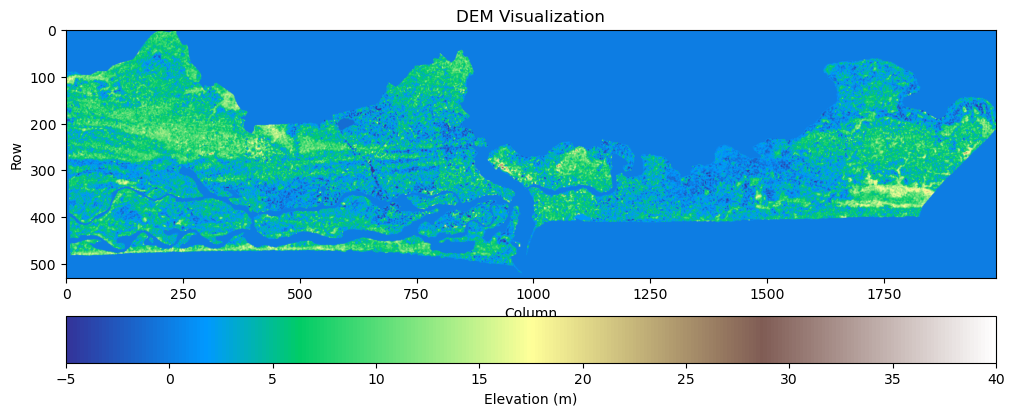

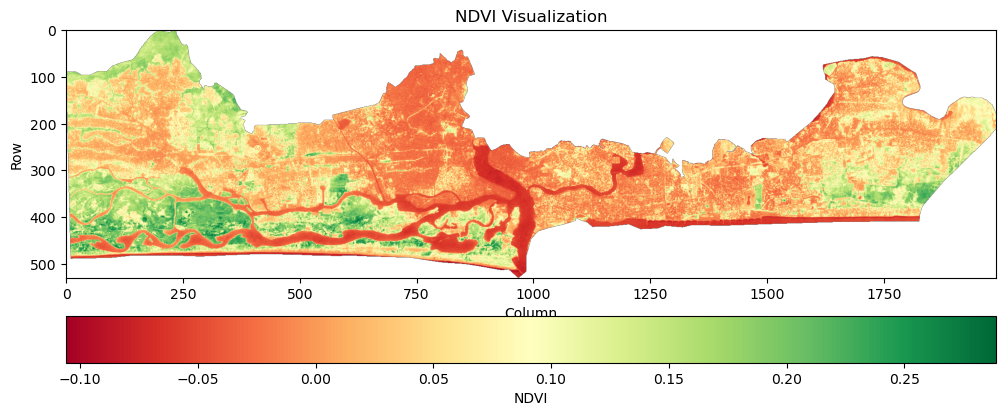

CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Bounds: BoundingBox(left=3.1366474775601336, bottom=6.389177626771685, right=3.672941702179488, top=6.532009756946689)
Unique class values: [0 1 2 4 5 7 8]


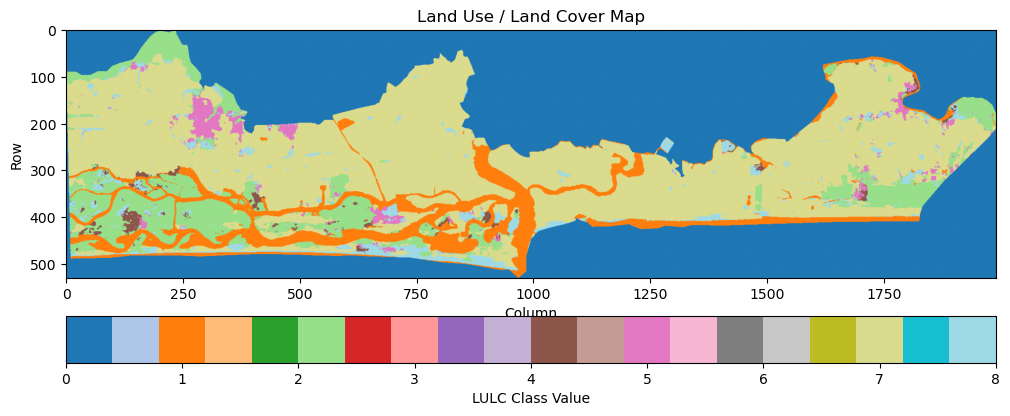

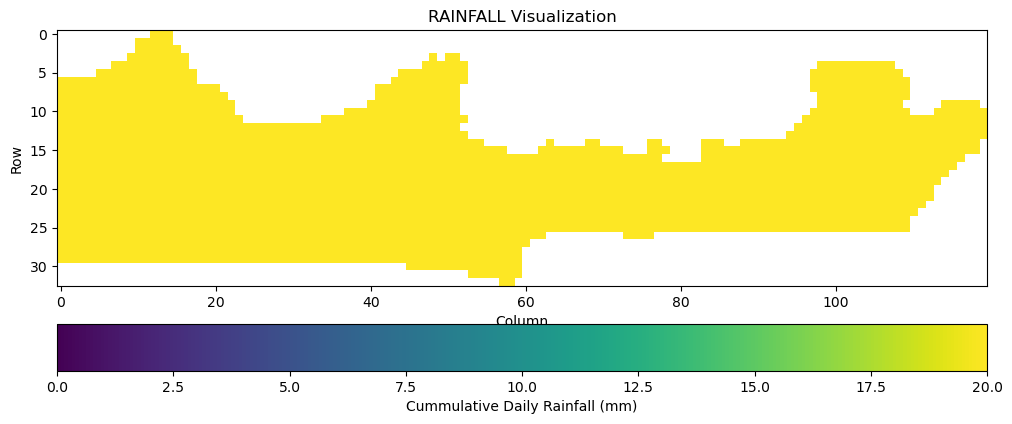

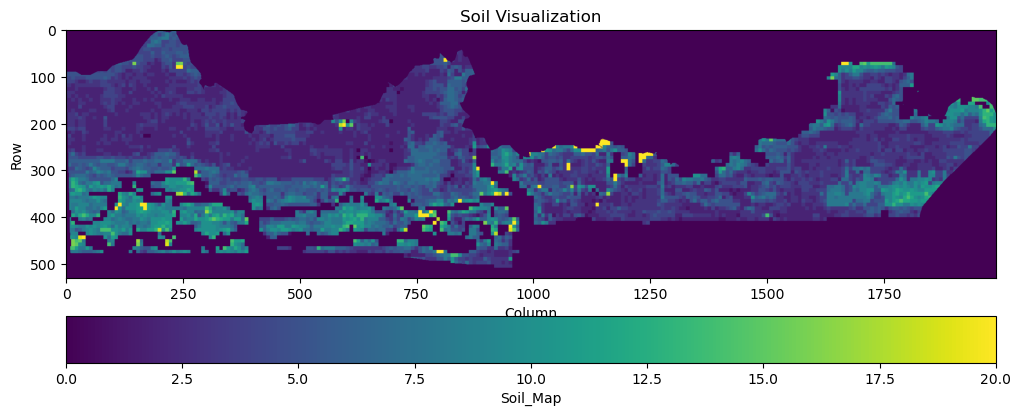

In [39]:
#---------DATA VISUALISATION----------#

os.chdir(r"C:/ENGO680_PROJECT_GROUP6/INPUT_DATA_GEE/GEE_EXPORTS")

#---------VISUALISATION OF DEM DATA----------#
dem_file = 'DEM.tif'
# Open DEM with rasterio
with rasterio.open(dem_file) as src:
    dem_data = src.read(1)         # Read the first band
    dem_bounds = src.bounds
    dem_transform = src.transform
plt.figure(figsize=(12,10))
plt.imshow(dem_data, cmap='terrain', vmin=-5, vmax=40)
plt.colorbar(label='Elevation (m)',  orientation='horizontal', pad=0.05)
plt.title('DEM Visualization')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

#---------VISUALISATION OF NDVI DATA----------#
ndvi_file = 'NDVI.tif'

with rasterio.open(ndvi_file) as src:
    ndvi_data = src.read(1)         # Read the first band
    ndvi_bounds = src.bounds
    ndvi_transform = src.transform

plt.figure(figsize=(12,10))
plt.imshow(ndvi_data, cmap='RdYlGn')  # Green for high vegetation
plt.colorbar(label='NDVI', orientation='horizontal', pad=0.05)
plt.title('NDVI Visualization')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

#---------VISUALISATION OF LULC DATA----------#
lulc_file = 'LULC.tif'

with rasterio.open(lulc_file) as src:
    lulc = src.read(1)
    bounds = src.bounds
    crs = src.crs

print("CRS:", crs)
print("Bounds:", bounds)
print("Unique class values:", np.unique(lulc))

plt.figure(figsize=(12,10))
# Basic colormap for categorical data
plt.imshow(lulc, cmap='tab20')
plt.colorbar(label='LULC Class Value', orientation='horizontal', pad=0.05)
plt.title('Land Use / Land Cover Map')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

#---------VISUALISATION  of RAINFALL DATA ----------#
rain_file = 'RAIN.tif'
with rasterio.open(rain_file) as src:
    rain_data = src.read(1)         # Read the first band
    rain_bounds = src.bounds
    rain_transform = src.transform

plt.figure(figsize=(12,10))
plt.imshow(rain_data, cmap='viridis', vmin=0, vmax=20)
plt.colorbar(label='Cummulative Daily Rainfall (mm)', orientation='horizontal', pad=0.05)
plt.title('RAINFALL Visualization')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

#---------VISUALISATION of SOIL PROPERTIES DATA ----------#
soil_file = 'SOIL.tif'

with rasterio.open(soil_file) as src:
    soil_data = src.read(1)         # Read the first band
    soil_bounds = src.bounds
    soil_transform = src.transform

plt.figure(figsize=(12,10))
plt.imshow(soil_data, cmap='viridis', vmin=0, vmax=20)
plt.colorbar(label='Soil_Map', orientation='horizontal', pad=0.05)
plt.title('Soil Visualization')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

In [ ]:
#---------VISUALISATION OF PERMANENT SURFACE WATER ----------#
SW_file = "PERMANENT_SURFACE_WATER.tif"
with rasterio.open(SW_file) as src:
    SW_data = src.read(1)         # Read the first band
    SW_bounds = src.bounds
    SW_transform = src.transform
plt.figure(figsize=(10,8))
plt.imshow(SW_data, cmap=('RdYlGn'), vmin=0, vmax=100)
plt.colorbar(label='Surface_Water_Range', orientation='horizontal', pad=100)
plt.title('PERMANENT_SURFACE_WATER_MAP')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

# PHASE 4 - DERIVATION OF HYDROLOGICAL-TERRAIN FLOOD PREDICTORS 
# (Slope, Topographical Wetness Index (TWI), Stream Power Index (SPI) and Curvature)

In [43]:
#Import tools for the derivation of the hydrological-terrain data 
from whitebox import WhiteboxTools# Initialize the tool
wbt = WhiteboxTools()
wbt.work_dir = "C:/ENGO680_PROJECT_GROUP6/INPUT_DATA_GEE/GEE_EXPORTS"

In [44]:
#---------DERIVATION OF HYDROLOGICAL-TERRAIN DATA  ----------#

# Define raster names for the derived data
dem = "DEM.tif"
slope = "SLOPE.tif"
twi = "TWI.tif"
spi = "SPI.tif"
curvature = "TOTAL_CURVATURE.tif"

filled_dem = "filled_DEM.tif"            
wbt.fill_depressions(dem, output=filled_dem)
wbt.slope(filled_dem, slope, 1.0, 'degrees') #Slope comuptation (degrees)
flow_accum = "flow_accum.tif"
wbt.d8_flow_accumulation(filled_dem, flow_accum, "specific_catchment_area")
flow_dir = "flow_dir.tif"
wbt.d8_pointer(filled_dem, flow_dir)
wbt.run_tool("WetnessIndex", [f"--sca={flow_accum}", f"--slope={slope}", f"-o={twi}"]) #Topographical Wetness Index comuptation 

slope_rad = "slope_radians.tif"
wbt.slope(filled_dem, slope_rad, 1.0, 'radians')  #Slope comuptation (radians)

wbt.run_tool("StreamPowerIndex", [f"--sca={flow_accum}", f"--slope={slope_rad}", f"-o={spi}"]) #Stream Power Index computation

wbt.run_tool("TotalCurvature", [f"-i={filled_dem}", f"-o={curvature}"]) #Curvature comuptation 

.\whitebox_tools.exe --run="FillDepressions" --wd="C:/ENGO680_PROJECT_GROUP6/INPUT_DATA_GEE/GEE_EXPORTS" --dem='DEM.tif' --output='filled_DEM.tif' --fix_flats -v --compress_rasters=False

******************************
* Welcome to FillDepressions *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding pit cells: 12%
Finding pit cells: 25%
Finding pit cells: 37%
Finding pit cells: 50%
Finding pit cells: 62%
Finding pit cells: 75%
Finding pit cells: 87%
Finding pit cells: 100%
Filling depressions: 0%
Filling depressions: 1%
Filling depressions: 2%
Filling depressions: 3%
Filling depressions: 4%
Filling depressions: 5%
Filling depressions: 6%
Filling depressions: 7%
Filling depressions: 8%
Filling depressions: 9%
Filling depressions: 10%
Filling depressions: 11%
Filling depressions: 12%
Filling depressions: 13%
Filling depressions: 14%
Filling depressions: 15%
Filling depressions: 16%
Filling depressions: 17%
Filling depressi

0

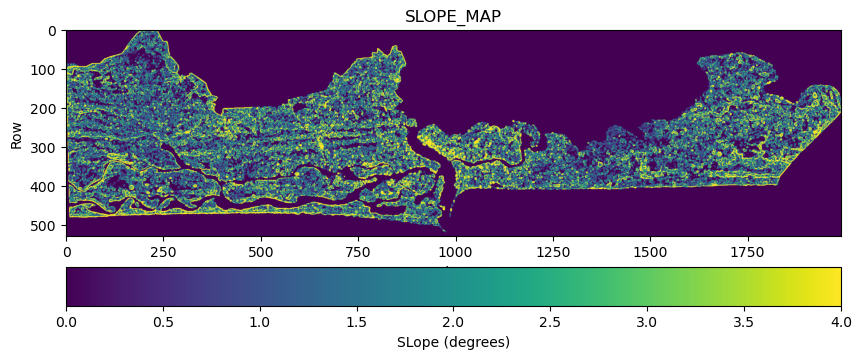

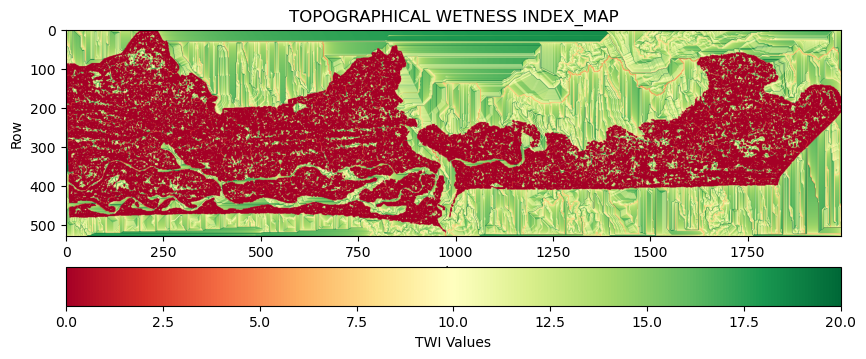

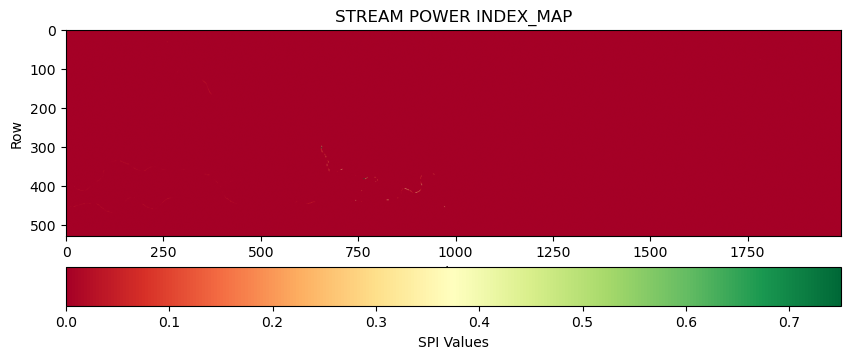

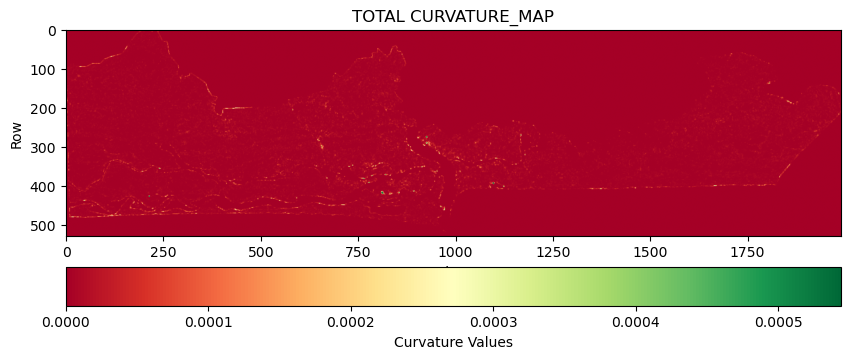

In [45]:
#---------VISUALISATION OF SLOPE DATA----------#

slope_file = 'SLOPE.tif'
with rasterio.open(slope_file) as src:
    slope_data = src.read(1)         # Read the first band
    slope_bounds = src.bounds
    slope_transform = src.transform

plt.figure(figsize=(10,8))
plt.imshow(slope_data, cmap='viridis', vmin=0, vmax=4)
plt.colorbar(label='SLope (degrees)', orientation='horizontal', pad=0.05)
plt.title('SLOPE_MAP')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

#---------VISUALISATION OF TOPOGRAPHICAL WETNESS INDEX (TWI)----------#
twi_file = 'TWI.tif'
with rasterio.open(twi_file) as src:
    twi_data = src.read(1)         # Read the first band
    twi_bounds = src.bounds
    twi_transform = src.transform

plt.figure(figsize=(10,8))
plt.imshow(twi_data, cmap=('RdYlGn'), vmin=0, vmax=20)
plt.colorbar(label='TWI Values', orientation='horizontal', pad=0.05)
plt.title('TOPOGRAPHICAL WETNESS INDEX_MAP')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

#---------VISUALISATION OF STREAM POWER INDEX (SPI)----------#
spi_file = 'SPI.tif'
with rasterio.open(spi_file) as src:
    spi_data = src.read(1)         # Read the first band
    spi_bounds = src.bounds
    spi_transform = src.transform

plt.figure(figsize=(10,8))
plt.imshow(spi_data, cmap=('RdYlGn'), vmin=0, vmax=0.75)
plt.colorbar(label='SPI Values', orientation='horizontal', pad=0.05)
plt.title('STREAM POWER INDEX_MAP')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

#---------VISUALISATION OF TOTAL CURVATURE DATA----------#
curvature_file = 'TOTAL_CURVATURE.tif'
with rasterio.open(curvature_file) as src:
    c_data = src.read(1)         # Read the first band
    c_bounds = src.bounds
    c_transform = src.transform

plt.figure(figsize=(10,8))
plt.imshow(c_data, cmap=('RdYlGn'), vmin=0, vmax=0.0005439125)
plt.colorbar(label='Curvature Values', orientation='horizontal', pad=0.05)
plt.title('TOTAL CURVATURE_MAP')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

# PHASE 5 -  IMPORT AND VISUALISE FLOOD INVENTORY RASTER FOR PREPROCESSING

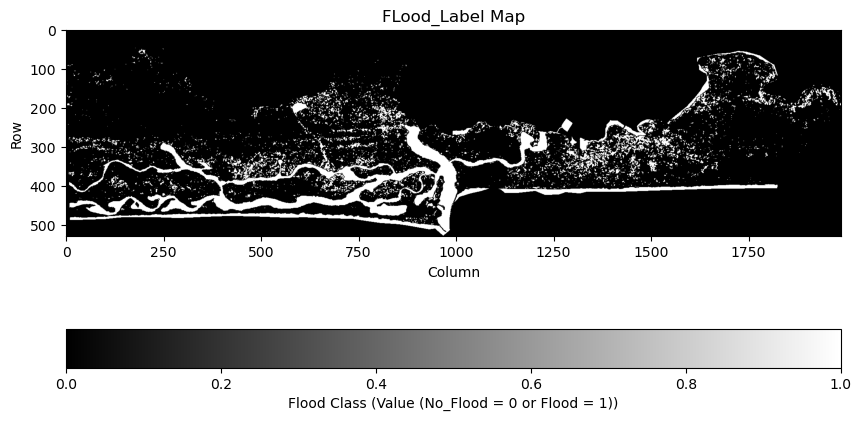

In [84]:
#Import Flood Inventory Raster for processing
os.chdir(r"C:/ENGO680_PROJECT_GROUP6/STUDY_AREA")

#Visualise Flood Inventory Raster
FLood_Label = 'FLOOD_INVENTORY_RASTER.tif'
with rasterio.open(FLood_Label) as src:
    FL_data = src.read(1)         # Read the first band
    FL_bounds = src.bounds
    FL_transform = src.transform
plt.figure(figsize=(10,8))
plt.imshow(c_data, cmap='gray')
plt.colorbar(label='Flood Class (Value (No_Flood = 0 or Flood = 1))', orientation = 'horizontal')
plt.title('FLood_Label Map')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

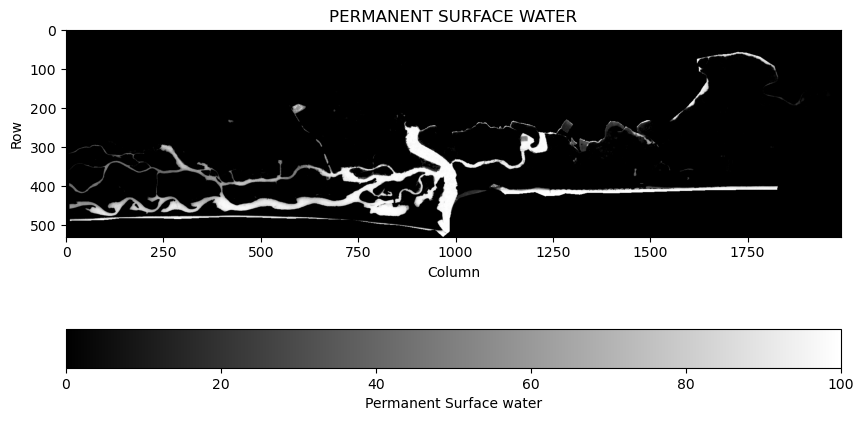

In [91]:
#Visualise Permanent Surface Water Raster initially downloaded
os.chdir(r"C:/ENGO680_PROJECT_GROUP6/INPUT_DATA_GEE/GEE_EXPORTS")
SW = 'PERMANENT_SURFACE_WATER.tif'
with rasterio.open(SW) as src:
    SW_data = src.read(1)         # Read the first band
    SW_bounds = src.bounds
    SW_transform = src.transform
plt.figure(figsize=(10,8))
plt.imshow(SW_data, cmap='gray',vmin = 0, vmax=100)
plt.colorbar(label='Permanent Surface water', orientation = 'horizontal')
plt.title('PERMANENT SURFACE WATER')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

In [122]:
#-------COMPUTE NUMBER OF FLOOD AND NON-FLOOD PIXELS------#

path = r"C:/ENGO680_PROJECT_GROUP6/STUDY_AREA/FLOOD_INVENTORY_RASTER.tif"

with rasterio.open(path) as src:
    arr = src.read(1)
    nodata = src.nodata

# Remove NoData if used
if nodata is not None:
    arr = arr[arr != nodata]

# Count classes
flood_pixels = np.sum(arr == 1)
non_flood_pixels = np.sum(arr == 0)

print("Flood pixels (value=1):", flood_pixels)
print("Non-flood pixels (value=0):", non_flood_pixels)
print("Total counted:", flood_pixels + non_flood_pixels)

Flood pixels (value=1): 104614
Non-flood pixels (value=0): 946509
Total counted: 1051123


In [42]:
#-------MASK OUT PERMAMMENT SURFACE WATER BODY AND CONVERT TO A BINARY RASTER------#
from rasterio.warp import reproject, Resampling

with rasterio.open(r"C:/ENGO680_PROJECT_GROUP6/STUDY_AREA/FLOOD_INVENTORY_RASTER.tif") as fir:
    template = fir
    template_profile = fir.profile

with rasterio.open(r"C:/ENGO680_PROJECT_GROUP6/INPUT_DATA_GEE/GEE_EXPORTS/PERMANENT_SURFACE_WATER.tif") as src:
    water_mask = np.zeros((template.height, template.width), dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=water_mask,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=template.transform,
        dst_crs=template.crs,
        resampling=Resampling.nearest
    )
threshold = 10
water_mask_bool = (water_mask > threshold).astype(np.uint8)   # convert to 0/1 integers

# --- SAVE THE MASK ---
out_profile = template_profile.copy()
out_profile.update({
    "dtype": "uint8",
    "count": 1
})

with rasterio.open("WATER_MASK_FINAL.tif", "w", **out_profile) as dst:
    dst.write(water_mask_bool, 1)


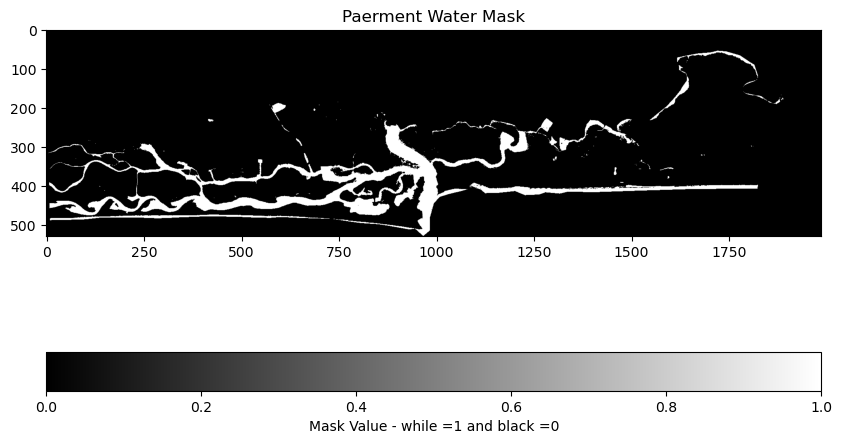

In [43]:
# --- DEFINE PATH TO WATER MASK RASTER ---
water_mask = "WATER_MASK_FINAL.tif"   

# --- OPEN & READ THE WATER MASK RASTER ---
with rasterio.open(water_mask) as src:
    mask = src.read(1)

# --- VISUALISE WATER MASK RASTER ---
plt.figure(figsize=(10, 10))
plt.imshow(mask, cmap='gray')   # white = 1, black = 0
plt.title("Paerment Water Mask")
plt.colorbar(label="Mask Value - while =1 and black =0", orientation = 'horizontal')
plt.show()

# PHASE 6 
# 1. PROCESSING OF FLOOD INVENTORY RASTER (MASKING OUT ALL PERMAMENT WATERBODIES (SURFACE WATER) FROM IT)
# 2. RESAMPLING OF ALL PREDICTIOR RASTERS TO 30M RESOLUTION (DEM, SOIL, NDVI, LULC, RAINFALL, TWI, SPI, CURVATURE, SLOPE)
# 3. EXTRACT FLOOD LABEL POINTS FROM PROCESSED FLOOD INVENTORY RASTER
# 4. USE THE EXTRACTED POINTS IN STEP 3 TO EXTRACT THE FEATURE VALUES FROM PREDICTOR RASTERS

In [44]:
files = os.listdir(r"C:/ENGO680_PROJECT_GROUP6/INPUT_DATA_GEE/GEE_EXPORTS")
print(files)

['DEM.tif', 'filled_DEM.tif', 'FLOOD_INVENTORY_RASTER.tif', 'flow_accum.tif', 'flow_dir.tif', 'LULC.tif', 'NDVI.tif', 'PERMANENT_SURFACE_WATER.tif', 'RAIN.tif', 'SLOPE.tif', 'slope_radians.tif', 'SOIL.tif', 'SPI.tif', 'TOTAL_CURVATURE.tif', 'TWI.tif', 'WATER_MASK_FINAL.tif']


In [45]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling
import numpy as np
import pandas as pd
from sklearn.utils import resample
import os
import geopandas as gpd
from shapely.geometry import Point

# =======================================================
# SETUP
# =======================================================

# Your inputs
flood_raster_path = r"C:/ENGO680_PROJECT_GROUP6/STUDY_AREA/FLOOD_INVENTORY_RASTER.tif"

predictor_dir = r"C:/ENGO680_PROJECT_GROUP6/INPUT_DATA_GEE/GEE_EXPORTS"

predictor_rasters = [
    "DEM.tif", "LULC.tif", "NDVI.tif", "RAIN.tif", "SLOPE.tif",
    "SOIL.tif", "SPI.tif", "TOTAL_CURVATURE.tif", "TWI.tif"
]

predictor_rasters = [os.path.join(predictor_dir, r) for r in predictor_rasters
                    ]
water_mask_raster = "WATER_MASK_FINAL.tif"

# Create output folders
masked_data = os.makedirs("C:/ENGO680_PROJECT_GROUP6/OUTPUT/MASKED_DATA", exist_ok=True)
output_resampled_data = os.makedirs("C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA", exist_ok=True)
model_data = os.makedirs("C:/ENGO680_PROJECT_GROUP6/OUTPUT/MODEL_DATA", exist_ok=True)

print("Created output folders: OUTPUT/MASKED, OUTPUT/RESAMPLED, OUTPUT/DATA")

TARGET_RES = 30


Created output folders: OUTPUT/MASKED, OUTPUT/RESAMPLED, OUTPUT/DATA


In [47]:
# =======================================================
# 1) MASK OUT PERMANENT WATERBODIES IN FLOOD INVENTORY
# =======================================================
print("\n===== STEP 1: MASKING PERMANENT WATER =====")

# Correct: define the directory as a string, THEN create it
masked_data = "C:/ENGO680_PROJECT_GROUP6/OUTPUT/MASKED_DATA"
os.makedirs(masked_data, exist_ok=True)

# Build output file path inside that directory
masked_flood_path = os.path.join(masked_data, "flood_masked.tif")

with rasterio.open(flood_raster_path) as flood_src, rasterio.open(water_mask_raster) as wm_src:

    flood = flood_src.read(1)
    water = wm_src.read(1).astype(bool)

    # Apply mask
    flood_masked = np.where(water, -9999, flood)

    # Update profile
    profile = flood_src.profile
    profile.update(dtype="int16", nodata=-9999)

    # Save output
    with rasterio.open(masked_flood_path, "w", **profile) as dst:
        dst.write(flood_masked.astype("int16"), 1)

print(f"Flood raster masked → {masked_flood_path}")


===== STEP 1: MASKING PERMANENT WATER =====
Flood raster masked → C:/ENGO680_PROJECT_GROUP6/OUTPUT/MASKED_DATA\flood_masked.tif


In [48]:
# =======================================================
# 2) RESAMPLE ALL RASTERS TO 30m USING FLOOD MASK AS REFERENCE
# =======================================================

import os
import rasterio
from rasterio.enums import Resampling

# FIX: define the output folder correctly
output_resampled_data = r"C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA"
os.makedirs(output_resampled_data, exist_ok=True)

resampled_predictors = []

print("\n===== STEP 2: RESAMPLING PREDICTOR RASTERS TO 30 m =====")

with rasterio.open(masked_flood_path) as ref:

    for rst in predictor_rasters:   # rst is an ABSOLUTE PATH

        filename = os.path.splitext(os.path.basename(rst))[0]
        out_path = os.path.join(output_resampled_data, f"{filename}_30m.tif")

        resampled_predictors.append(out_path)

        with rasterio.open(rst) as src:
            data = src.read(
                out_shape=(src.count, ref.height, ref.width),
                resampling=Resampling.bilinear
            )

            profile = src.profile.copy()
            profile.update({
                "height": ref.height,
                "width": ref.width,
                "transform": ref.transform,
                "crs": ref.crs
            })

            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(data)

        print(f"Resampled → {out_path}")

print("All predictors successfully resampled.")


===== STEP 2: RESAMPLING PREDICTOR RASTERS TO 30 m =====
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\DEM_30m.tif
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\LULC_30m.tif
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\NDVI_30m.tif
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\RAIN_30m.tif
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\SLOPE_30m.tif
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\SOIL_30m.tif
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\SPI_30m.tif
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\TOTAL_CURVATURE_30m.tif
Resampled → C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\TWI_30m.tif
All predictors successfully resampled.


In [56]:
# 3) STRATIFIED SAMPLING (15%)
# =======================================================
from sklearn.model_selection import train_test_split
print("\n===== STEP 3: STRATIFIED SAMPLING (15%) =====")

with rasterio.open(masked_flood_path) as src:

    arr = src.read(1)
    transform = src.transform

    valid = arr >= 0
    labels = arr[valid]

    coords = np.column_stack(np.where(valid))

    sample_fraction = 0.15

    sampled_idx, _ = train_test_split(
        coords,
        test_size=1 - sample_fraction,
        stratify=labels,
        random_state=42)

points = []
sampled_labels = []

for r, c in sampled_idx:
    x, y = rasterio.transform.xy(transform, r, c)
    points.append(Point(x, y))
    sampled_labels.append(arr[r, c])

gdf = gpd.GeoDataFrame({"label": sampled_labels, "geometry": points}, crs=src.crs)

print(f"Sampled {len(gdf)} points (15% of valid pixels).")


===== STEP 3: STRATIFIED SAMPLING (15%) =====
Sampled 146816 points (15% of valid pixels).


In [103]:
# =======================================================
# 4) EXTRACT FEATURE VALUES FROM PREDICTOR RASTERS
# =======================================================
print("STEP 4: Extracting feature values...")

resampled_predictors = list(dict.fromkeys(resampled_predictors))

for rst in resampled_predictors:
    
    # --- FIX: normalize path ---
    clean_rst = rst.replace("\\", "/")
    
    # extract only the filename, drop extension, remove "_30m"
    col_name = os.path.splitext(os.path.basename(clean_rst))[0].replace("_30m", "")
    
    values = []

    with rasterio.open(rst) as src:
        band = src.read(1)

        for point in gdf.geometry:
            row, col = src.index(point.x, point.y)
            values.append(band[row, col])

    gdf[col_name] = values

# =======================================================
# FIX DATATYPES 
# =======================================================
for col in gdf.columns:
    if col not in ["geometry", "label"]:     # skip non-raster fields
        if pd.api.types.is_integer_dtype(gdf[col]):
            gdf[col] = gdf[col].astype(float)

# =======================================================
# CLEAN UP DUPLICATE + PATH COLUMNS
# =======================================================
gdf = gdf[[col for col in gdf.columns if not col.endswith("_30m")]]
gdf = gdf[[col for col in gdf.columns if "/" not in col and "\\" not in col]]
gdf = gdf.loc[:, ~gdf.columns.duplicated()]

print("Cleaned columns:", gdf.columns.tolist())

STEP 4: Extracting feature values...
Cleaned columns: ['label', 'geometry', 'DEM', 'LULC', 'NDVI', 'RAIN', 'SLOPE', 'SOIL', 'SPI', 'TOTAL_CURVATURE', 'TWI']


# PHASE 7 MODEL DATA FINAL PROCESSING AND CLEANING (REMOVAL OF NODATA AND NAN VALUES)

In [104]:
model_data_dir = "C:/ENGO680_PROJECT_GROUP6/OUTPUT/MODEL_DATA"
os.makedirs(model_data_dir, exist_ok=True)

# ----- Save GeoJSON -----
model_data_geojson = os.path.join(model_data_dir, "extracted_model_data.geojson")
gdf.to_file(model_data_geojson, driver="GeoJSON")

# ----- Save CSV (geometry → WKT string) -----
model_data_csv = os.path.join(model_data_dir, "extracted_model_data.csv")
gdf.to_csv(model_data_csv, index=False)

print("Saved extracted predictor values:")
print(f"  GeoJSON done → {model_data_geojson}")
print(f"  CSV done   → {model_data_csv}")

Saved extracted predictor values:
  GeoJSON done → C:/ENGO680_PROJECT_GROUP6/OUTPUT/MODEL_DATA\extracted_model_data.geojson
  CSV done   → C:/ENGO680_PROJECT_GROUP6/OUTPUT/MODEL_DATA\extracted_model_data.csv


In [105]:
model_data_csv = "C:/ENGO680_PROJECT_GROUP6/OUTPUT/MODEL_DATA/extracted_model_data.csv"
# Load CSV
df_csv = pd.read_csv(model_data_csv)
df_csv.head()
#print(df_csv.columns.tolist())

,label,geometry,DEM,LULC,NDVI,RAIN,SLOPE,SOIL,SPI,TOTAL_CURVATURE,TWI
0,0,POINT (548875.4053817802 706920.5014061994),0.0,0.0,NaN,NaN,1.651217e-06,0.0,2.582386e-13,1.080867e-17,12.095714
1,0,POINT (521094.23217545875 719841.2833593006),4.0,3.0,0.155210,268.194744,7.585481e-02,2.0,1.513312e-08,1.390903e-07,8.735508
2,0,POINT (547025.3165108974 713007.8905942655),7.0,7.0,0.058030,440.292331,4.400040e-01,3.0,5.159677e-08,5.284521e-07,2.455154
3,0,POINT (567316.6138044511 713216.7715958168),7.0,7.0,0.078601,566.217322,2.125157e+00,3.0,2.050791e-07,8.900322e-06,-4.680522
4,0,POINT (549263.327241804 718737.1980653866),0.0,0.0,NaN,NaN,1.425932e-07,0.0,1.350180e-14,6.672358e-21,11.701097


In [110]:
print("\n===== REMOVING NaN / NoData ROWS =====")

# Work on df_csv (already loaded earlier)
df_csv = df_csv.copy()

# Identify predictor columns (everything except geometry + label)
predictor_cols = [col for col in df_csv.columns if col not in ["geometry", "label"]]

# Remove rows where ANY predictor is NaN
df_csv = df_csv.dropna(subset=predictor_cols)

print(f"Rows after removal: {len(df_csv)}")

# Save cleaned version (without geometry)
df_csv_no_geom = df_csv.drop(columns=["geometry"])
df_csv_no_geom.to_csv(
    "C:/ENGO680_PROJECT_GROUP6/OUTPUT/MODEL_DATA/cleaned_model_data.csv",
    index=False)

print("Saved → cleaned_model_data.csv")


===== REMOVING NaN / NoData ROWS =====
Rows after removal: 68515
Saved → cleaned_model_data.csv


# PHASE 8
# MACHINE LEARNING MODEL IMPLEMENTATION 

In [113]:
#----LOAD CLEANED, PROCESSED AND PREPARED MODEL DATA---------#
model_data = pd.read_csv("C:/ENGO680_PROJECT_GROUP6/OUTPUT/MODEL_DATA/cleaned_model_data.csv")

In [114]:
model_data.head()

,label,DEM,LULC,NDVI,RAIN,SLOPE,SOIL,SPI,TOTAL_CURVATURE,TWI
0,0,4.0,3.0,0.155210,268.194744,0.075855,2.0,1.513312e-08,1.390903e-07,8.735508
1,0,7.0,7.0,0.058030,440.292331,0.440004,3.0,5.159677e-08,5.284521e-07,2.455154
2,0,7.0,7.0,0.078601,566.217322,2.125157,3.0,2.050791e-07,8.900322e-06,-4.680522
3,0,3.0,7.0,-0.006200,433.448071,1.353874,3.0,1.111432e-07,3.307020e-06,-4.447072
4,0,4.0,7.0,0.197376,530.618025,0.146161,8.0,1.405010e-07,1.836642e-07,9.425363


In [60]:
# =====================================================
# CHECK FOR CLASS IMBALANCE
# =====================================================

# Set your flood column name
label = "label"    # flood label column name here (string)

# Count classes
counts = model_data[label].value_counts()
percent = model_data[label].value_counts(normalize=True) * 100

# Chat-style display
print("===== CLASS IMBALANCE CHECK =====")
print(f"Total samples: {len(model_data)}")

for cls in counts.index:
    print(f"Class {cls}: {counts[cls]} samples ({percent[cls]:.2f}%)")

print("=================================")

===== CLASS IMBALANCE CHECK =====
Total samples: 68515
Class 0: 62533 samples (91.27%)
Class 1: 5982 samples (8.73%)


# PHASE 8 (PART 1) - MODEL DEVELOPMENT IMPLEMENTATION (SELECTED ALGORITHMS - RANDOM FOREST AND EXTREME GRADIENT BOOSTING (XGBOOST))
# (INITIAL MODEL DEVELOPMENT AND WITHOUT HYPERPARAMETER OPTIMIZATION)

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# =====================================================
# 1) PREPARE DATA
# =====================================================
X = model_data.drop(columns=["label"])
y = model_data["label"]

# =====================================================
# 2) STRATIFIED TRAIN–TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.3, stratify=y, random_state=42)

In [62]:
# =====================================================
# COMPUTE CLASS WEIGHT (DUE TO CLASS IMBALANCE)
# =====================================================

class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
cw = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights:", cw)

Class Weights: {0: np.float64(0.5478262856098508), 1: np.float64(5.727251015046573)}



===== ACCURACY RESULTS =====
RF  Train Accuracy: 1.0000
RF  Test  Accuracy: 0.9657
XGB Train Accuracy: 0.9568
XGB Test  Accuracy: 0.9385

===== AUC SCORES =====
Random Forest AUC: 0.9791
XGBoost AUC:       0.9814


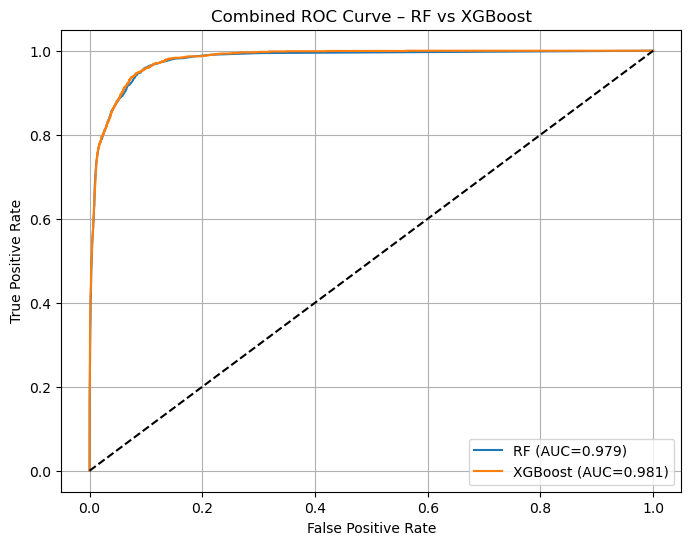

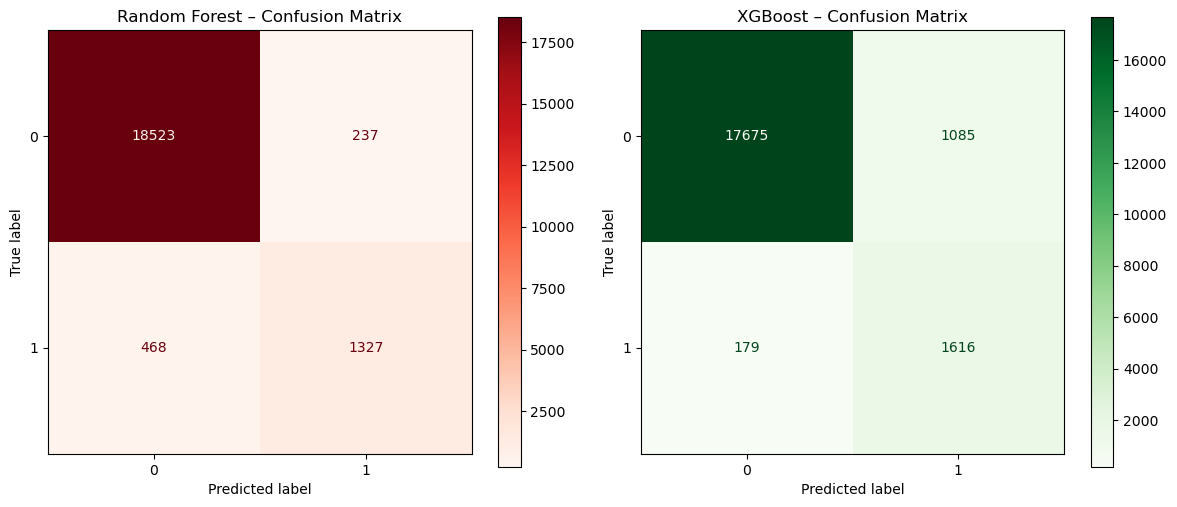

In [63]:

# ======================================================
# RANDOM FOREST (RF) AND EXTREME GRADIENT BOOSTING (XGBOOST)
# ======================================================

rf = RandomForestClassifier(n_estimators=300, max_depth=None,
    class_weight=cw, random_state=42)

rf.fit(X_train, y_train)

neg, pos = np.bincount(y_train)
scale = neg / pos
#print("XGB scale_pos_weight:", scale)

xgb = XGBClassifier(n_estimators=400, learning_rate=0.05,
    max_depth=6, subsample=0.9, colsample_bytree=0.9,
    objective="binary:logistic", scale_pos_weight=scale,
    eval_metric="logloss", random_state=42)

xgb.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test,  rf.predict(X_test))

xgb_train_acc = accuracy_score(y_train, xgb.predict(X_train))
xgb_test_acc  = accuracy_score(y_test,  xgb.predict(X_test))

print("\n===== ACCURACY RESULTS =====")
print(f"RF  Train Accuracy: {rf_train_acc:.4f}")
print(f"RF  Test  Accuracy: {rf_test_acc:.4f}")
print(f"XGB Train Accuracy: {xgb_train_acc:.4f}")
print(f"XGB Test  Accuracy: {xgb_test_acc:.4f}")

rf_test_proba  = rf.predict_proba(X_test)[:, 1]
xgb_test_proba = xgb.predict_proba(X_test)[:, 1]

rf_auc  = roc_auc_score(y_test, rf_test_proba)
xgb_auc = roc_auc_score(y_test, xgb_test_proba)

print("\n===== AUC SCORES =====")
print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"XGBoost AUC:       {xgb_auc:.4f}")


fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={rf_auc:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.3f})")
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve – RF vs XGBoost")
plt.legend()
plt.grid(True)
plt.show()

# ======================================================
# PREDICTIONS (RANDOM FOREST AND XGBOOST)
# ======================================================
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

# ======================================================
# CONFUSION MATRICES FOR RANDOM FOREST AND XGBOOST
# ======================================================
cm_rf  = confusion_matrix(y_test, rf_pred)
cm_xgb = confusion_matrix(y_test, xgb_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- RANDOM FOREST CONFUSION MATRIX---
disp_rf = ConfusionMatrixDisplay(cm_rf)
disp_rf.plot(ax=axes[0], cmap="Reds", values_format="d")
axes[0].set_title("Random Forest – Confusion Matrix")

# --- XGBOOST CONFUSION MATRIX---
disp_xgb = ConfusionMatrixDisplay(cm_xgb)
disp_xgb.plot(ax=axes[1], cmap="Greens", values_format="d")
axes[1].set_title("XGBoost – Confusion Matrix")

plt.tight_layout()
plt.show()

In [64]:
# ======================================================
# PRINT RESULTS FOR BOTH CLASSIFIERS/MODELS
# ======================================================
print("\n===== RANDOM FOREST =====")
print("Training Accuracy:", rf_train_acc)
print("Test Accuracy:", rf_test_acc)
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("AUC:", rf_auc)
print(classification_report(y_test, rf_pred, zero_division=0))

print("\n===== XGBOOST =====")
print("Training Accuracy:", xgb_train_acc)
print("Test Accuracy:", xgb_test_acc)
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("AUC:", xgb_auc)
print(classification_report(y_test, xgb_pred, zero_division=0))


===== RANDOM FOREST =====
Training Accuracy: 1.0
Test Accuracy: 0.9657017757236682
Precision: 0.84846547314578
Recall: 0.7392757660167131
F1 Score: 0.7901161059839238
AUC: 0.9790697923039005
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     18760
           1       0.85      0.74      0.79      1795

    accuracy                           0.97     20555
   macro avg       0.91      0.86      0.89     20555
weighted avg       0.96      0.97      0.96     20555


===== XGBOOST =====
Training Accuracy: 0.9567764804003336
Test Accuracy: 0.9385064461201654
Precision: 0.5982969270640504
Recall: 0.9002785515320334
F1 Score: 0.7188612099644128
AUC: 0.9813500246479502
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     18760
           1       0.60      0.90      0.72      1795

    accuracy                           0.94     20555
   macro avg       0.79      0.92      0.84     20555
weight

# PHASE 8 (PART 2) - SECOND MODEL DEVELOPMENT IMPLEMENTATION 
# (SECOND SET OF MODEL DEVELOPMENT AND HYPERPARAMETER OPTIMIZATION)


In [109]:
# ======================================================
# RANDOM FOREST 
# ======================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# =====================================================
# 1) STRATIFIED TRAIN–TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42)

# =====================================================
# 2) INITIAL RANDOM FOREST (used for random search)
# =====================================================
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

# =====================================================
# 3) RANDOMIZED SEARCH CV — HYPERPARAMETER SEARCH
# =====================================================
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    "bootstrap":       [True, False]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,                   # sample 40 combinations
    scoring='f1_macro',          # Considering the fact that its an imbalance
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=True)

# ---- Fit RandomizedSearchCV ----
random_search.fit(X_train, y_train)

# =====================================================
# 4) PRINT BEST PARAMETERS + BEST CV SCORE
# =====================================================
print("\n===== BEST PARAMETERS FOUND =====")
print(random_search.best_params_)

print("\nBest 5-Fold CV F1 Macro Score:")
print(random_search.best_score_)

# =====================================================
# 5) RETRAIN BEST MODEL ON TRAINING SET
# =====================================================
best_rf = random_search.best_estimator_
best_rf.fit(X_train, y_train)

# =====================================================
# 6) PREDICTIONS AND METRICS FOR RANDOM FOREST 
# =====================================================
rf_pred_1 = best_rf.predict(X_test)
rf_prob_1 = best_rf.predict_proba(X_test)[:, 1]

rf_train_acc_1 = accuracy_score(y_train, best_rf.predict(X_train))
print("\n===== RANDOM FOREST TRAINING ACCURACY =====")
print("Training Accuracy:", rf_train_acc_1)


print("\n===== RANDOM FOREST TEST SET RESULTS =====")
print("Accuracy:", accuracy_score(y_test, rf_pred_1))
print("Precision:", precision_score(y_test, rf_pred_1))
print("Recall:", recall_score(y_test, rf_pred_1))
print("F1 Score:", f1_score(y_test, rf_pred_1))
print("AUC:", roc_auc_score(y_test, rf_prob_1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred_1))
print("\nClassification Report:\n", classification_report(y_test, rf_pred_1))



Fitting 5 folds for each of 40 candidates, totalling 200 fits

===== BEST PARAMETERS FOUND =====
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 40, 'bootstrap': True}

Best 5-Fold CV F1 Macro Score:
0.8917816423655621

===== RANDOM FOREST TRAINING ACCURACY =====
Training Accuracy: 0.991534612176814

===== RANDOM FOREST TEST SET RESULTS =====
Accuracy: 0.9654098759425931
Precision: 0.8257211538461539
Recall: 0.7654596100278551
F1 Score: 0.7944492627927147
AUC: 0.9794095182662098

Confusion Matrix:
 [[18470   290]
 [  421  1374]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     18760
           1       0.83      0.77      0.79      1795

    accuracy                           0.97     20555
   macro avg       0.90      0.88      0.89     20555
weighted avg       0.96      0.97      0.96     20555



In [112]:
# ======================================================
# EXTREME GRADIENT BOOSTING (XGBOOST)
# ======================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# =====================================================
# 1) STRATIFIED TRAIN–TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42)

# =====================================================
# 2) COMPUTE SCALE_POS_WEIGHT (imbalance handling)
# =====================================================
neg = sum(y_train == 0)
pos = sum(y_train == 1)
scale_pos_weight = neg / pos

#print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# =====================================================
# 3) INITIAL XGBOOST MODEL (for RandomizedSearch)
# =====================================================
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    tree_method="auto",
    random_state=42,
    n_jobs=-1)

# =====================================================
# 4) PARAMETER DISTRIBUTIONS FOR RANDOMIZED SEARCH
# =====================================================
param_dist = {
    "n_estimators":      [200, 300, 400, 500],
    "max_depth":         [4, 6, 8, 10],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1],
    "subsample":         [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.7, 0.8, 1.0],
    "gamma":             [0, 0.1, 0.3, 0.5, 1],
    "min_child_weight":  [1, 3, 5, 7],
    "reg_alpha":         [0, 0.1, 0.5, 1.0],
    "reg_lambda":        [0.5, 1.0, 2.0, 5.0] }

# =====================================================
# 5) 5-FOLD STRATIFIED CV FOR SEARCH
# =====================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,                     
    scoring="f1_macro",           
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=True)

# ---- Fit RandomizedSearchCV ----
random_search_xgb.fit(X_train, y_train)

# =====================================================
# 6) PRINT BEST PARAMETERS + BEST CV SCORE
# =====================================================
print("\n===== BEST PARAMETERS (XGBoost) =====")
print(random_search_xgb.best_params_)

print("\nBest 5-Fold CV F1 Macro Score:")
print(random_search_xgb.best_score_)

# =====================================================
# 7) RETRAIN BEST MODEL
# =====================================================
best_xgb = random_search_xgb.best_estimator_
best_xgb.fit(X_train, y_train)

# =====================================================
# 8) PREDICTION AND METRICS XGBOOST
# =====================================================
xgb_pred_1 = best_xgb.predict(X_test)
xgb_prob_1 = best_xgb.predict_proba(X_test)[:, 1]

xgb_train_acc_1 = accuracy_score(y_train,  best_xgb.predict(X_train))
print("\n===== XGBOOST TRAINING ACCURACY =====")
print("Training Accuracy:", xgb_train_acc_1)


print("\n===== XGBOOST TEST SET RESULTS =====")
print("Accuracy:", accuracy_score(y_test, xgb_pred_1))
print("Precision:", precision_score(y_test, xgb_pred_1))
print("Recall:", recall_score(y_test, xgb_pred_1))
print("F1 Score:", f1_score(y_test, xgb_pred_1))
print("AUC:", roc_auc_score(y_test, xgb_prob_1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_pred_1))
print("\nClassification Report:\n", classification_report(y_test, xgb_pred_1))


Fitting 5 folds for each of 40 candidates, totalling 200 fits

===== BEST PARAMETERS (XGBoost) =====
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}

Best 5-Fold CV F1 Macro Score:
0.8786517761259098

===== XGBOOST TRAINING ACCURACY =====
Training Accuracy: 0.9962677231025855

===== XGBOOST TEST SET RESULTS =====
Accuracy: 0.9584042811967891
Precision: 0.7402862985685071
Recall: 0.8066852367688022
F1 Score: 0.7720607837909891
AUC: 0.9807667888175516

Confusion Matrix:
 [[18252   508]
 [  347  1448]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98     18760
           1       0.74      0.81      0.77      1795

    accuracy                           0.96     20555
   macro avg       0.86      0.89      0.87     20555
weighted avg       0.96      0.96      0.96     20555



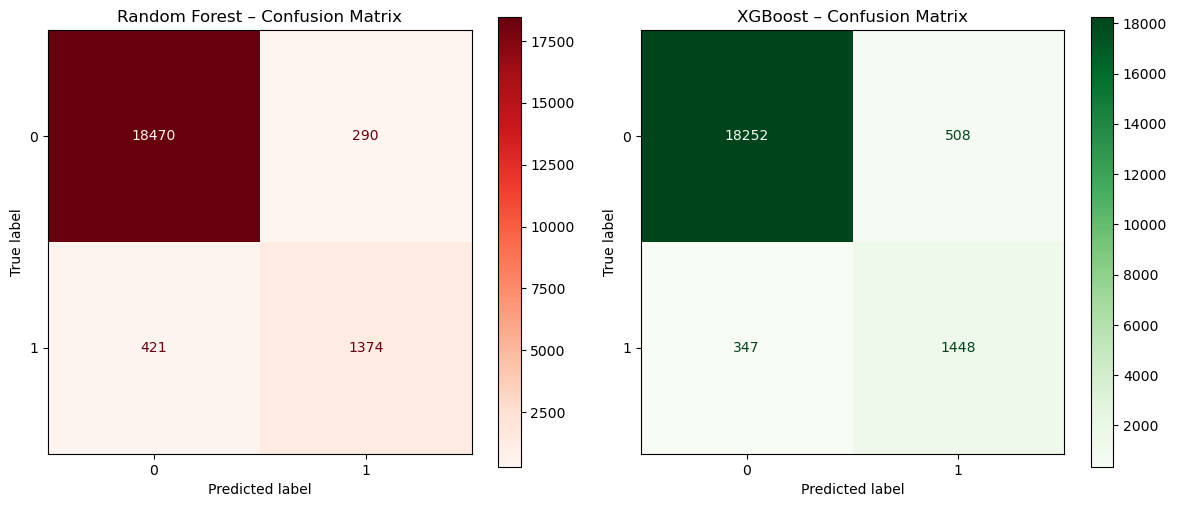

In [71]:
# ======================================================
# CONFUSION MATRICES FOR RANDOM FOREST AND XGBOOST (AFTER OPTIMIZATION OF HYPERPARAMETERS)
# ======================================================
cm_rf  = confusion_matrix(y_test, rf_pred_1)
cm_xgb = confusion_matrix(y_test, xgb_pred_1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- RANDOM FOREST ---
disp_rf = ConfusionMatrixDisplay(cm_rf)
disp_rf.plot(ax=axes[0], cmap="Reds", values_format="d")
axes[0].set_title("Random Forest – Confusion Matrix")

# --- XGBOOST---
disp_xgb = ConfusionMatrixDisplay(cm_xgb)
disp_xgb.plot(ax=axes[1], cmap="Greens", values_format="d")
axes[1].set_title("XGBoost – Confusion Matrix")

plt.tight_layout()
plt.show()

RF PR-AUC: 0.8651181377888039
XGB PR-AUC: 0.8654565090312558


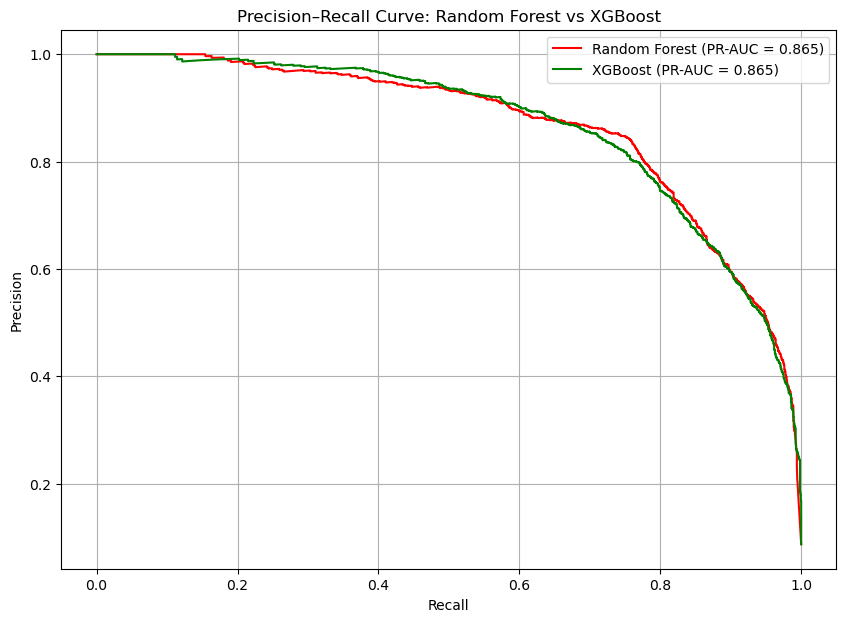

In [72]:
# ======================================================
# PRECISION-RECALL CURVE FOR RANDOM FOREST AND XGBOOST (AFTER OPTIMIZATION OF HYPERPARAMETERS)
# ======================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get probability predictions
rf_probs  = best_rf.predict_proba(X_test)[:, 1]
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

# Compute precision–recall curves
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_probs)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_probs)

# Compute PR-AUC
rf_pr_auc  = average_precision_score(y_test, rf_probs)
xgb_pr_auc = average_precision_score(y_test, xgb_probs)

print("RF PR-AUC:", rf_pr_auc)
print("XGB PR-AUC:", xgb_pr_auc)

plt.figure(figsize=(10, 7))

plt.plot(rf_recall, rf_precision, 
         label=f"Random Forest (PR-AUC = {rf_pr_auc:.3f})", 
         color="red")

plt.plot(xgb_recall, xgb_precision, 
         label=f"XGBoost (PR-AUC = {xgb_pr_auc:.3f})", 
         color="green")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve: Random Forest vs XGBoost")
plt.legend()
plt.grid(True)
plt.show()


# PHASE 8 (PART 3) - THIRD MODEL DEVELOPMENT IMPLEMENTATION 
# 1. FEATURE (PREDICTOR) SELECTION USING MUTUAL INFORMATION, RANDOM FOREST FEATURE IMPORTANCE FROM SECOND MODEL AND XGBOOST GAIN IMPORTANCE FROM SECOND MODEL
# 2. MODEL DEVELOPMENT USING SELECTED FEATURES (PREDICTORS) AS INPUT FEATURES AND THE OPTIMISED HYPERPARAMETERS IN SECOND MODELS


In [73]:
# ======================================================
# FEATURE SELECTION USING MUTUAL INFORMATION
# ======================================================

from sklearn.feature_selection import mutual_info_classif

# Identify categorical columns 
categorical_cols = ["LULC", "SOIL"]   # Categorical Input features
all_columns = X.columns.tolist()

# Mark categorical = True/False for each column
discrete_mask = [col in categorical_cols for col in all_columns]

# Compute MI
mi_scores = mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=42)

mi_df = pd.DataFrame({
    "feature": all_columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

print("\n===== MUTUAL INFORMATION SCORES =====")
print(mi_df.to_string(index=False))




===== MUTUAL INFORMATION SCORES =====
        feature  mutual_information
            DEM            0.203398
            TWI            0.066659
          SLOPE            0.050086
TOTAL_CURVATURE            0.043797
            SPI            0.035126
           RAIN            0.017249
           NDVI            0.008083
           SOIL            0.005393
           LULC            0.005195


In [74]:
# ======================================================
# FEATURE IMPORTANCE CHECK FOR RANDOM FOREST 
# ======================================================

rf_feat_imp = pd.DataFrame({
    "feature": all_columns,
    "rf_importance": best_rf.feature_importances_
}).sort_values("rf_importance", ascending=False)

print("\n===== RANDOM FOREST FEATURE IMPORTANCE =====")
print(rf_feat_imp.to_string(index=False))



===== RANDOM FOREST FEATURE IMPORTANCE =====
        feature  rf_importance
            DEM       0.602544
            TWI       0.136326
          SLOPE       0.080882
TOTAL_CURVATURE       0.057446
            SPI       0.047202
           NDVI       0.035278
           RAIN       0.018263
           SOIL       0.015847
           LULC       0.006213


In [75]:
# ======================================================
# FEATURE IMPORTANCE CHECK FOR XGBOOST 
# ======================================================

xgb_gain_dict = best_xgb.get_booster().get_score(importance_type="gain")

# Convert to DataFrame aligned with your column order
xgb_gain = []
for col in all_columns:
    xgb_gain.append(xgb_gain_dict.get(col, 0))   # 0 if XGB didn’t use the feature

xgb_feat_imp = pd.DataFrame({
    "feature": all_columns,
    "xgb_gain_importance": xgb_gain
}).sort_values("xgb_gain_importance", ascending=False)

print("\n===== XGBOOST GAIN IMPORTANCE =====")
print(xgb_feat_imp.to_string(index=False))



===== XGBOOST GAIN IMPORTANCE =====
        feature  xgb_gain_importance
            DEM           245.803619
          SLOPE             5.693710
TOTAL_CURVATURE             4.780870
           RAIN             4.424582
            SPI             4.211302
           NDVI             4.193959
            TWI             4.141743
           LULC             3.956321
           SOIL             3.762484


In [76]:
# ========================================================================================
# COMBINING AND PRINTING THE VALUES FOR ALL FEATURE SELECTION/IMPORTANCE CHECK METHODS
# ========================================================================================

combined = mi_df.merge(rf_feat_imp, on="feature").merge(xgb_feat_imp, on="feature")
combined = combined.sort_values(
    ["mutual_information", "rf_importance", "xgb_gain_importance"],
    ascending=False)

print("\n===== COMBINED FEATURE IMPORTANCE TABLE =====")
print(combined.to_string(index=False))



===== COMBINED FEATURE IMPORTANCE TABLE =====
        feature  mutual_information  rf_importance  xgb_gain_importance
            DEM            0.203398       0.602544           245.803619
            TWI            0.066659       0.136326             4.141743
          SLOPE            0.050086       0.080882             5.693710
TOTAL_CURVATURE            0.043797       0.057446             4.780870
            SPI            0.035126       0.047202             4.211302
           RAIN            0.017249       0.018263             4.424582
           NDVI            0.008083       0.035278             4.193959
           SOIL            0.005393       0.015847             3.762484
           LULC            0.005195       0.006213             3.956321


In [117]:
# ==================================================================================================
# MODEL DEVELOPMENT USING SELECTED FEATURES (TOP SIX) AND THE OPTIMISED PARAMETERS FROM SECOND MODEL
# ==================================================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier

# =====================================================
# 1) SELECTED FEATURES
# =====================================================
modelB_features = ["DEM", "TWI", "SLOPE", "TOTAL_CURVATURE", "SPI", "RAIN"]

X_B = X[modelB_features].copy()
y_B = y.copy()

print("Model B dataset shape:", X_B.shape)

# =====================================================
# 2) TRAIN–TEST SPLIT
# =====================================================
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B,
    test_size=0.3,
    stratify=y_B,
    random_state=42)

# =====================================================
# 3) CLASS WEIGHTS FOR IMBALANCE
# =====================================================
# balanced class weights automatically adjust to training data imbalance
rf_B = RandomForestClassifier(
    n_estimators=best_rf.n_estimators,
    max_depth=best_rf.max_depth,
    min_samples_split=best_rf.min_samples_split,
    min_samples_leaf=best_rf.min_samples_leaf,
    max_features=best_rf.max_features,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)

# =====================================================
# 4) TRAIN MODEL (RF)
# =====================================================
rf_B.fit(X_train_B, y_train_B)

# =====================================================
# 5) EVALUATE MODEL 
# =====================================================
pred_RF_B = rf_B.predict(X_test_B)
prob_RF_B = rf_B.predict_proba(X_test_B)[:, 1]

rf_train_acc_2 = accuracy_score(y_train_B,  rf_B.predict(X_train_B))
print("\n===== RANDOM FOREST TRAINING ACCURACY =====")
print("Training Accuracy:", rf_train_acc_2)

print("\n===== RANDOM FOREST (THIRD MODEL) =====")
print("Accuracy :", accuracy_score(y_test_B, pred_RF_B))
print("Precision:", precision_score(y_test_B, pred_RF_B))
print("Recall   :", recall_score(y_test_B, pred_RF_B))
print("F1 Score :", f1_score(y_test_B, pred_RF_B))
print("ROC-AUC  :", roc_auc_score(y_test_B, prob_RF_B))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_B, pred_RF_B))

print("\nClassification Report:")
print(classification_report(y_test_B, pred_RF_B))

# =====================================================
# 6) PRECISION–RECALL CURVE (PR-AUC)
# =====================================================
prec_B, rec_B, _ = precision_recall_curve(y_test_B, prob_RF_B)
pr_auc_RF_B = average_precision_score(y_test_B, prob_RF_B)

print("\nPR-AUC (RF Model B):", pr_auc_RF_B)

Model B dataset shape: (68515, 6)

===== RANDOM FOREST TRAINING ACCURACY =====
Training Accuracy: 0.990325271059216

===== RANDOM FOREST (THIRD MODEL) =====
Accuracy : 0.9642422768182923
Precision: 0.8074245939675174
Recall   : 0.7754874651810585
F1 Score : 0.7911338448422848
ROC-AUC  : 0.9781225389170345

Confusion Matrix:
[[18428   332]
 [  403  1392]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18760
           1       0.81      0.78      0.79      1795

    accuracy                           0.96     20555
   macro avg       0.89      0.88      0.89     20555
weighted avg       0.96      0.96      0.96     20555


PR-AUC (RF Model B): 0.86224268457324


In [118]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve)
from xgboost import XGBClassifier

# =====================================================
# 1) SELECTED FEATURES
# =====================================================
modelB_features = ["DEM", "TWI", "SLOPE", "TOTAL_CURVATURE", "SPI", "RAIN"]

X_B = X[modelB_features].copy()
y_B = y.copy()

print("Model B dataset shape:", X_B.shape)

# =====================================================
# 2) TRAIN–TEST SPLIT
# =====================================================
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B,
    test_size=0.3,
    stratify=y_B,
    random_state=42)

# =====================================================
# 3) COMPUTE scale_pos_weight FROM TRAINING SET ONLY
# =====================================================
neg = (y_train_B == 0).sum()
pos = (y_train_B == 1).sum()
scale_pos_weight_B = neg / pos

# =====================================================
# 4) BUILD XGBOOST USING BEST PARAMS FROM YOUR OLD MODEL
# =====================================================
xgb_B = XGBClassifier(
    n_estimators=best_xgb.n_estimators,
    max_depth=best_xgb.max_depth,
    learning_rate=best_xgb.learning_rate,
    subsample=best_xgb.subsample,
    colsample_bytree=best_xgb.colsample_bytree,
    gamma=best_xgb.gamma,
    min_child_weight=best_xgb.min_child_weight,
    reg_alpha=best_xgb.reg_alpha,
    reg_lambda=best_xgb.reg_lambda,
    scale_pos_weight=scale_pos_weight_B,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1)

# =====================================================
# 5) TRAIN THE MODEL
# =====================================================
xgb_B.fit(X_train_B, y_train_B)

# =====================================================
# 6) EVALUATE MODEL PERFORMANCE
# =====================================================
pred_XGB_B = xgb_B.predict(X_test_B)
prob_XGB_B = xgb_B.predict_proba(X_test_B)[:, 1]

xgb_train_acc_2 = accuracy_score(y_train_B,  xgb_B.predict(X_train_B))
print("\n===== RANDOM FOREST TRAINING ACCURACY =====")
print("Training Accuracy:", xgb_train_acc_2)

print("\n===== XGBOOST THRID MODEL RESULTS =====")
print("Accuracy :", accuracy_score(y_test_B, pred_XGB_B))
print("Precision:", precision_score(y_test_B, pred_XGB_B))
print("Recall   :", recall_score(y_test_B, pred_XGB_B))
print("F1 Score :", f1_score(y_test_B, pred_XGB_B))
print("ROC-AUC  :", roc_auc_score(y_test_B, prob_XGB_B))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_B, pred_XGB_B))

print("\nClassification Report:")
print(classification_report(y_test_B, pred_XGB_B))

# =====================================================
# 7) PRECISION–RECALL CURVE + PR-AUC
# =====================================================
prec_B, rec_B, _ = precision_recall_curve(y_test_B, prob_XGB_B)
pr_auc_XGB_B = average_precision_score(y_test_B, prob_XGB_B)

print("\nPR-AUC (XGB Model B):", pr_auc_XGB_B)

Model B dataset shape: (68515, 6)

===== RANDOM FOREST TRAINING ACCURACY =====
Training Accuracy: 0.9902210175145955

===== XGBOOST THRID MODEL RESULTS =====
Accuracy : 0.9553393334954999
Precision: 0.7111218103033221
Recall   : 0.822841225626741
F1 Score : 0.7629132231404959
ROC-AUC  : 0.9796990574386326

Confusion Matrix:
[[18160   600]
 [  318  1477]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     18760
           1       0.71      0.82      0.76      1795

    accuracy                           0.96     20555
   macro avg       0.85      0.90      0.87     20555
weighted avg       0.96      0.96      0.96     20555


PR-AUC (XGB Model B): 0.8583241738888798



===== CONFUSION MATRX FOR MODEL B =====


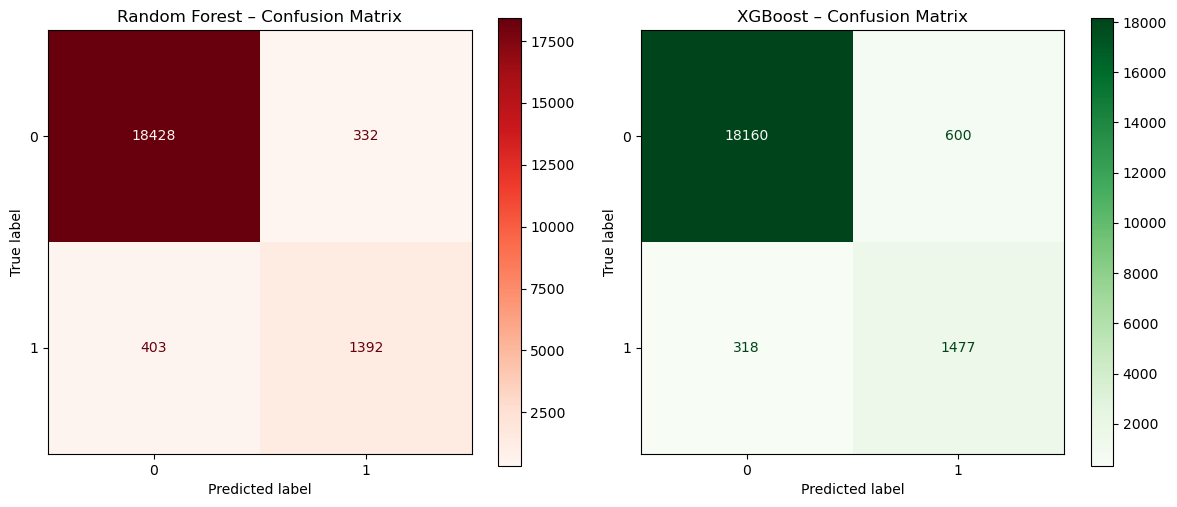

RF PR-AUC: 0.86224268457324
XGB PR-AUC: 0.8583241738888798


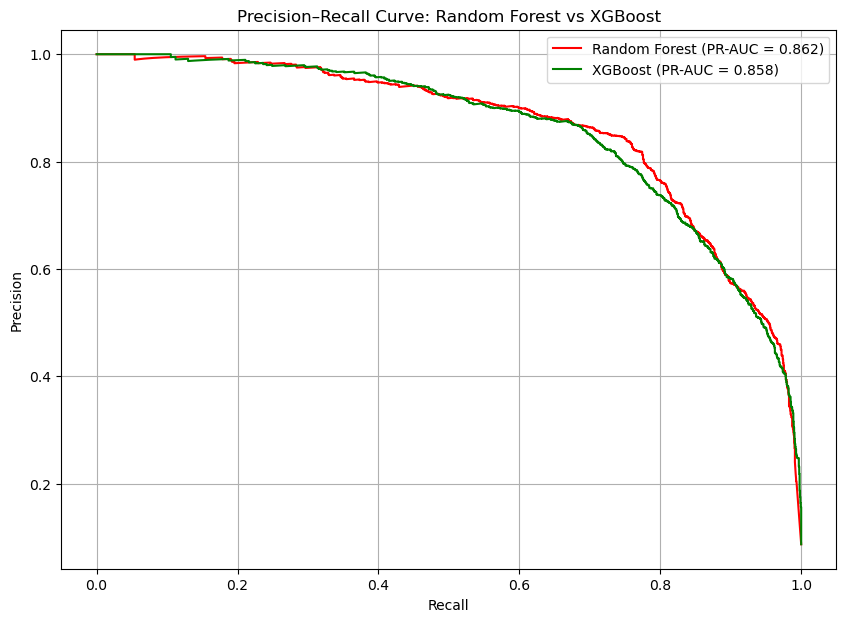

In [111]:
# ======================================================
# CONFUSION MATRICES FOR RANDOM FOREST AND XGBOOST
# ======================================================
cm_rf  = confusion_matrix(y_test, pred_RF_B)
cm_xgb = confusion_matrix(y_test, pred_XGB_B)

print("\n===== CONFUSION MATRX FOR MODEL B =====")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# --- RANDOM FOREST---
disp_rf = ConfusionMatrixDisplay(cm_rf)
disp_rf.plot(ax=axes[0], cmap="Reds", values_format="d")
axes[0].set_title("Random Forest – Confusion Matrix")

# --- XGBoost ---
disp_xgb = ConfusionMatrixDisplay(cm_xgb)
disp_xgb.plot(ax=axes[1], cmap="Greens", values_format="d")
axes[1].set_title("XGBoost – Confusion Matrix")

plt.tight_layout()
plt.show()

#ROC CURVE
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get probability predictions
rf_probs  = best_rf.predict_proba(X_test)[:, 1]
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

# Compute precision–recall curves
rf_precision, rf_recall, _ = precision_recall_curve(y_test_B, prob_RF_B)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test_B, prob_XGB_B)

# Compute PR-AUC
rf_pr_auc  = average_precision_score(y_test_B, prob_RF_B)
xgb_pr_auc = average_precision_score(y_test_B, prob_XGB_B)

print("RF PR-AUC:", rf_pr_auc)
print("XGB PR-AUC:", xgb_pr_auc)

plt.figure(figsize=(10, 7))

plt.plot(rf_recall, rf_precision, 
         label=f"Random Forest (PR-AUC = {rf_pr_auc:.3f})", 
         color="red")

plt.plot(xgb_recall, xgb_precision, 
         label=f"XGBoost (PR-AUC = {xgb_pr_auc:.3f})", 
         color="green")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve: Random Forest vs XGBoost")
plt.legend()
plt.grid(True)
plt.show()


In [81]:
# ======================================================
# COMPARISON OF SECOND AND THIRD MODEL

# KINDLY NOTE THAT THE FOLLOWING:
# RF_FULL - RANDOM FOREST SECOND MODEL (WITH ALL FEATURES)
# XGB_FULL - XGBOOST SECOND MODEL (WITH ALL FEATURES)
# RF_MODELB - RANDOM FOREST THIRD MODEL (WITH SIX FEATURES)
# XGB_MODEL - XGBOOST  THIRD MODEL (WITH SIX FEATURES)
# =====================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, average_precision_score,
    precision_recall_curve, roc_curve)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------
# FULL MODELS
# --------------------
rf_full_pred = best_rf.predict(X_test)
rf_full_prob = best_rf.predict_proba(X_test)[:, 1]

xgb_full_pred = best_xgb.predict(X_test)
xgb_full_prob = best_xgb.predict_proba(X_test)[:, 1]

# --------------------
# MODEL B (Reduced Feature Models)
# --------------------
rf_B_pred = rf_B.predict(X_test_B)
rf_B_prob = rf_B.predict_proba(X_test_B)[:, 1]

xgb_B_pred = xgb_B.predict(X_test_B)
xgb_B_prob = xgb_B.predict_proba(X_test_B)[:, 1]

def model_metrics(y_true, pred, prob):
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, prob),
        "PR-AUC": average_precision_score(y_true, prob)
    }

results = pd.DataFrame({
    "RF_Full": model_metrics(y_test, rf_full_pred, rf_full_prob),
    "XGB_Full": model_metrics(y_test, xgb_full_pred, xgb_full_prob),
    "RF_ModelB": model_metrics(y_test_B, rf_B_pred, rf_B_prob),
    "XGB_ModelB": model_metrics(y_test_B, xgb_B_pred, xgb_B_prob),
}).T

print("\n===== MODEL COMPARISON TABLE =====\n")
print(results)


===== MODEL COMPARISON TABLE =====

            Accuracy  Precision    Recall        F1   ROC-AUC    PR-AUC
RF_Full     0.965410   0.825721  0.765460  0.794449  0.979410  0.865118
XGB_Full    0.958404   0.740286  0.806685  0.772061  0.980767  0.865457
RF_ModelB   0.964242   0.807425  0.775487  0.791134  0.978123  0.862243
XGB_ModelB  0.955339   0.711122  0.822841  0.762913  0.979699  0.858324


In [91]:
import numpy as np
import pandas as pd
import rasterio
import os

# ============================================================
# 0) SETUP — YOUR FOLDER PATH
# ============================================================
predictor_folder = r"C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA"

# Model B feature names (MUST match the predictor rasters)
# and MUST be in the same order as used to train xgb_B and rf_B
modelB_features = ["DEM_30m", "TWI_30m", "SLOPE_30m", "TOTAL_CURVATURE_30m", "SPI_30m", "RAIN_30m"]

# Build full raster paths (assumes file names match exactly, e.g. DEM_30m.tif, TWI_30m.tif, etc.)
raster_paths = {
    feat: os.path.join(predictor_folder, f"{feat}.tif")
    for feat in modelB_features
}

# Output file paths
xgb_output_path = os.path.join(predictor_folder, "Flood_Susceptibility_XGB_ModelB.tif")
rf_output_path  = os.path.join(predictor_folder, "Flood_Susceptibility_RF_ModelB.tif")

print("Raster file paths:")
for k, v in raster_paths.items():
    print(k, ":", v)

# ============================================================
# 1) READ RASTERS AND CHECK ALIGNMENT
# ============================================================
bands = {}
nodata_vals = {}
reference_profile = None
reference_shape = None

for feat, path in raster_paths.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype("float32")
        nd = src.nodata

        if reference_profile is None:
            reference_profile = src.profile
            reference_shape = data.shape
        else:
            if data.shape != reference_shape:
                raise ValueError(
                    f"Raster {path} does not match shape {reference_shape}. "
                    "Resample/reproject before continuing."
                )

        bands[feat] = data
        nodata_vals[feat] = nd

rows, cols = reference_shape
print("\nAll rasters loaded. Shape =", reference_shape)

# ============================================================
# 2) BUILD GLOBAL MASK (IF ANY PIXEL IS INVALID)
# ============================================================
mask = np.zeros((rows, cols), dtype=bool)

for feat in modelB_features:
    arr = bands[feat]
    nd = nodata_vals[feat]

    # Mask nodata values
    if nd is not None:
        mask |= (arr == nd)

    # Mask NaN values
    mask |= np.isnan(arr)

print("Masked pixels:", mask.sum())

# ============================================================
# 3) STACK BANDS INTO DATAFRAME FOR PREDICTION
# ============================================================
flat_data = {feat: bands[feat].reshape(-1) for feat in modelB_features}
mask_flat = mask.reshape(-1)

df_pixels = pd.DataFrame(flat_data, columns=modelB_features)
valid_pixels = df_pixels[~mask_flat]

print("Total pixels:", df_pixels.shape[0])
print("Valid pixels:", valid_pixels.shape[0])

# ============================================================
# 4) RUN XGBOOST & RANDOM FOREST MODEL B (FLOOD SUSCEPTIBILITY 0–1)
# ============================================================
# IMPORTANT: xgb_B and rf_B MUST ALREADY BE TRAINED IN THIS SESSION
# We pass .values to avoid any feature-name mismatch issues.

# ---- XGBoost probabilities ----
probs_valid_xgb = xgb_B.predict_proba(valid_pixels.values)[:, 1]

sus_flat_xgb = np.full(df_pixels.shape[0], -9999.0, dtype="float32")
sus_flat_xgb[~mask_flat] = probs_valid_xgb
sus_xgb = sus_flat_xgb.reshape(rows, cols)

# ---- Random Forest probabilities ----
probs_valid_rf = rf_B.predict_proba(valid_pixels.values)[:, 1]

sus_flat_rf = np.full(df_pixels.shape[0], -9999.0, dtype="float32")
sus_flat_rf[~mask_flat] = probs_valid_rf
sus_rf = sus_flat_rf.reshape(rows, cols)

# ============================================================
# 5) WRITE OUTPUT FLOOD SUSCEPTIBILITY RASTERS
# ============================================================
out_profile = reference_profile.copy()
out_profile.update(
    dtype=rasterio.float32,
    count=1,
    nodata=-9999.0,
    compress="lzw"
)

# ---- XGBoost map ----
with rasterio.open(xgb_output_path, "w", **out_profile) as dst:
    dst.write(sus_xgb.astype("float32"), 1)

print("\nFlood susceptibility raster (XGBoost) SAVED TO:")
print(xgb_output_path)

# ---- Random Forest map ----
with rasterio.open(rf_output_path, "w", **out_profile) as dst:
    dst.write(sus_rf.astype("float32"), 1)

print("\nFlood susceptibility raster (Random Forest) SAVED TO:")
print(rf_output_path)


Raster file paths:
DEM_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\DEM_30m.tif
TWI_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\TWI_30m.tif
SLOPE_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\SLOPE_30m.tif
TOTAL_CURVATURE_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\TOTAL_CURVATURE_30m.tif
SPI_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\SPI_30m.tif
RAIN_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\RAIN_30m.tif

All rasters loaded. Shape = (529, 1987)
Masked pixels: 526447
Total pixels: 1051123
Valid pixels: 524676

Flood susceptibility raster (XGBoost) SAVED TO:
C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\Flood_Susceptibility_XGB_ModelB.tif

Flood susceptibility raster (Random Forest) SAVED TO:
C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\Flood_Susceptibility_RF_ModelB.tif


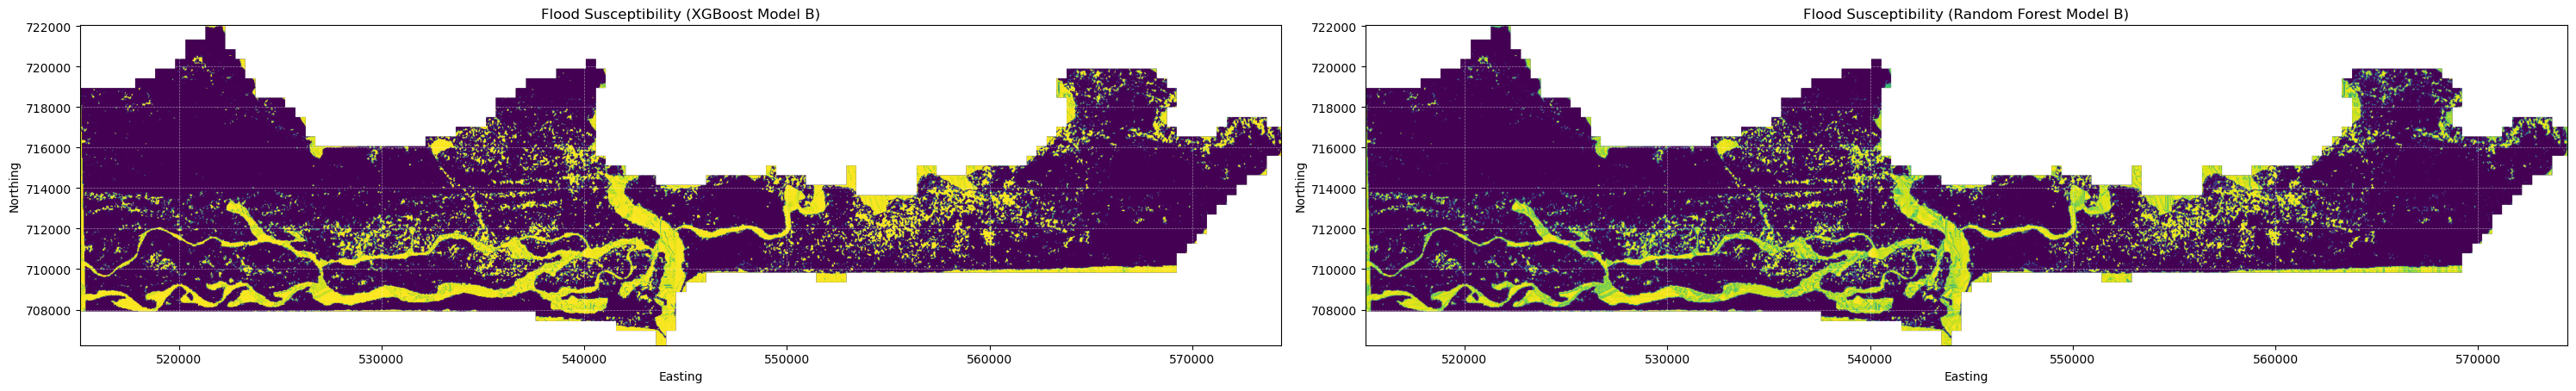

In [94]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Paths for both outputs
xgb_path = r"C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA/Flood_Susceptibility_XGB_ModelB.tif"
rf_path  = r"C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA/Flood_Susceptibility_RF_ModelB.tif"

# Open both rasters
with rasterio.open(xgb_path) as src_xgb, rasterio.open(rf_path) as src_rf:

    fig, axes = plt.subplots(1, 2, figsize=(30, 15))

    # Plot XGBoost map
    show(src_xgb, cmap="viridis", ax=axes[0])
    axes[0].set_title("Flood Susceptibility (XGBoost Model B)")
    axes[0].set_xlabel("Easting")
    axes[0].set_ylabel("Northing")
    axes[0].grid(color='white', linestyle='--', linewidth=0.5, alpha=0.5)

    # Plot Random Forest map
    show(src_rf, cmap="viridis", ax=axes[1])
    axes[1].set_title("Flood Susceptibility (Random Forest Model B)")
    axes[1].set_xlabel("Easting")
    axes[1].set_ylabel("Northing")
    axes[1].grid(color='white', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

Extent: [515111.28348816826, 574403.6477856556, 706249.0981869274, 722034.5338755891]


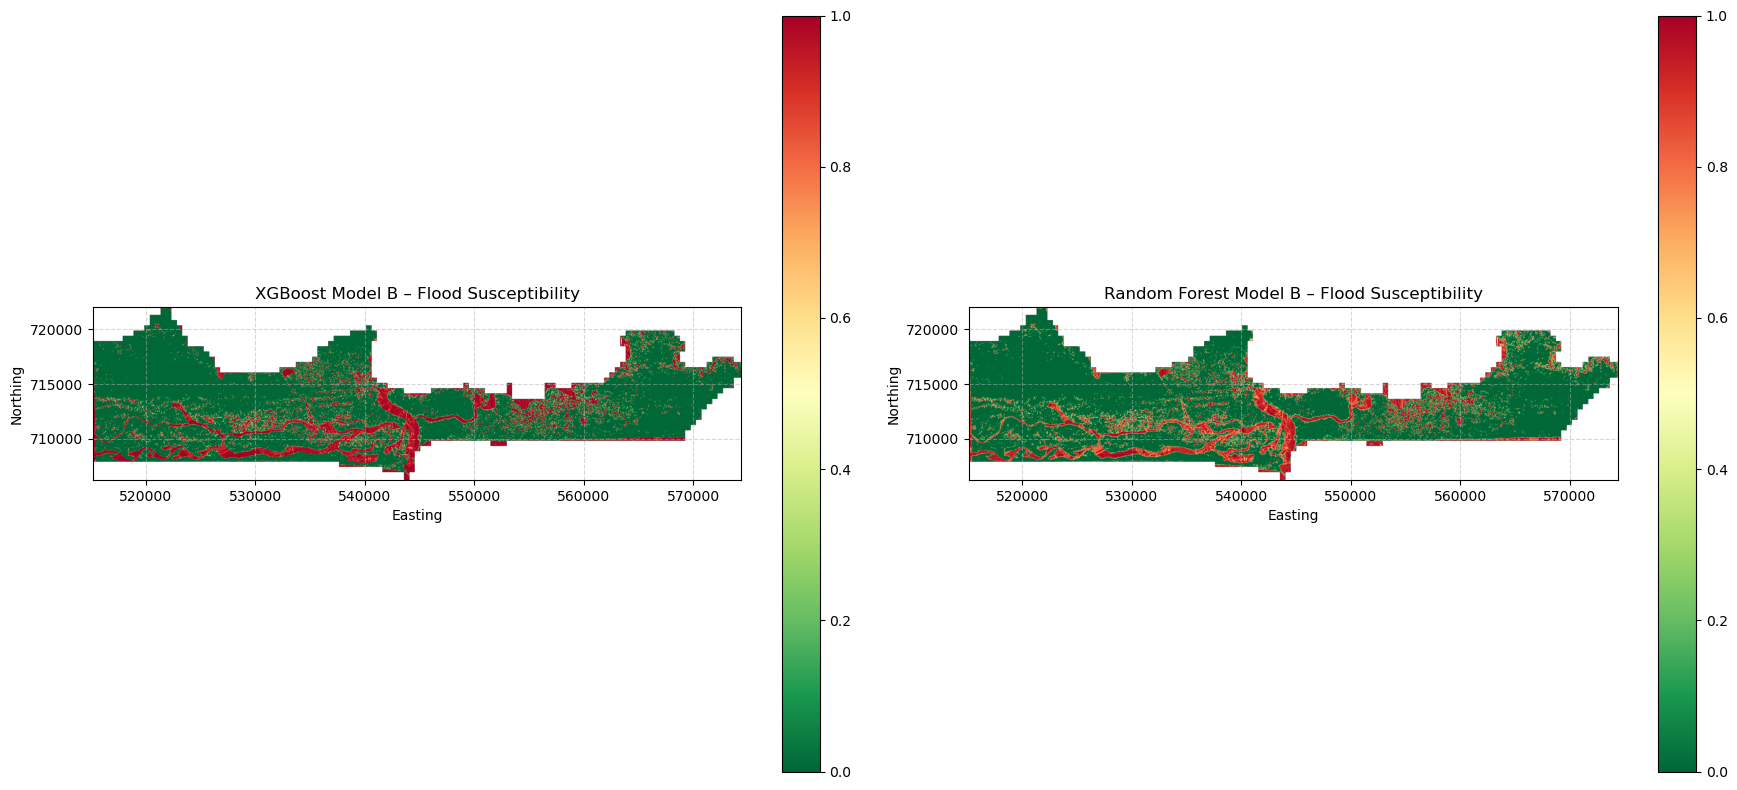

In [103]:
import numpy as np
import pandas as pd
import rasterio
import os
import matplotlib.pyplot as plt

# ============================================================
# 0) SETUP — FOLDER & FEATURES
# ============================================================
predictor_folder = r"C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA"

modelB_features = ["DEM_30m", "TWI_30m", "SLOPE_30m", "TOTAL_CURVATURE_30m", "SPI_30m", "RAIN_30m"]

raster_paths = {
    feat: os.path.join(predictor_folder, f"{feat}.tif")
    for feat in modelB_features
}

# ============================================================
# 1) READ RASTERS & GET GEOTRANSFORM
# ============================================================
bands = {}
nodata_vals = {}
reference_profile = None
reference_shape = None
transform = None

for feat, path in raster_paths.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype("float32")
        nd = src.nodata

        if reference_profile is None:
            reference_profile = src.profile
            reference_shape = data.shape
            transform = src.transform   # <-- GET TRANSFORM HERE
        else:
            if data.shape != reference_shape:
                raise ValueError("Rasters not aligned!")

        bands[feat] = data
        nodata_vals[feat] = nd

rows, cols = reference_shape

# Extract map extent from transform
left = transform.c
top = transform.f
right = left + cols * transform.a
bottom = top + rows * transform.e

extent = [left, right, bottom, top]

print("Extent:", extent)

# ============================================================
# 2) MASK INVALID PIXELS
# ============================================================
mask = np.zeros((rows, cols), dtype=bool)
for feat in modelB_features:
    arr = bands[feat]
    nd = nodata_vals[feat]
    if nd is not None:
        mask |= (arr == nd)
    mask |= np.isnan(arr)

mask_flat = mask.reshape(-1)

# ============================================================
# 3) STACK INTO DATAFRAME FOR PREDICTION
# ============================================================
flat_data = {feat: bands[feat].reshape(-1) for feat in modelB_features}
df_pixels = pd.DataFrame(flat_data, columns=modelB_features)
valid_pixels = df_pixels[~mask_flat]

# ============================================================
# 4) MODEL PREDICTIONS
# ============================================================
# XGBoost
probs_valid_xgb = xgb_B.predict_proba(valid_pixels.values)[:, 1]
sus_flat_xgb = np.full(df_pixels.shape[0], np.nan)
sus_flat_xgb[~mask_flat] = probs_valid_xgb
sus_xgb = sus_flat_xgb.reshape(rows, cols)

# Random Forest
probs_valid_rf = rf_B.predict_proba(valid_pixels.values)[:, 1]
sus_flat_rf = np.full(df_pixels.shape[0], np.nan)
sus_flat_rf[~mask_flat] = probs_valid_rf
sus_rf = sus_flat_rf.reshape(rows, cols)

# ============================================================
# 5) PLOT WITH REAL COORDINATES (extent)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost map
im1 = axes[0].imshow(sus_xgb, cmap="RdYlGn_r", vmin=0, vmax=1, extent=extent)
axes[0].set_title("XGBoost Model B – Flood Susceptibility")
axes[0].set_xlabel("Easting")
axes[0].set_ylabel("Northing")
axes[0].grid(True, linestyle="--", alpha=0.5)
plt.colorbar(im1, ax=axes[0])

# Random Forest map
im2 = axes[1].imshow(sus_rf, cmap="RdYlGn_r", vmin=0, vmax=1, extent=extent)
axes[1].set_title("Random Forest Model B – Flood Susceptibility")
axes[1].set_xlabel("Easting")
axes[1].set_ylabel("Northing")
axes[1].grid(True, linestyle="--", alpha=0.5)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

In [104]:
import numpy as np
import pandas as pd
import rasterio
import rasterio.transform
import os

# ============================================================
# 0) SETUP – FOLDER & FEATURES
# ============================================================
predictor_folder = r"C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA"

# MUST match raster names & model training feature order
modelB_features = ["DEM_30m", "TWI_30m", "SLOPE_30m",
                   "TOTAL_CURVATURE_30m", "SPI_30m", "RAIN_30m"]

# Build full raster paths
raster_paths = {
    feat: os.path.join(predictor_folder, f"{feat}.tif")
    for feat in modelB_features
}

# Output CSV paths (SEPARATE)
xgb_csv_path = os.path.join(predictor_folder, "Flood_Pixel_Data_XGB_ModelB.csv")
rf_csv_path  = os.path.join(predictor_folder, "Flood_Pixel_Data_RF_ModelB.csv")

print("Raster file paths:")
for k, v in raster_paths.items():
    print(k, ":", v)

# ============================================================
# 1) READ RASTERS & CHECK ALIGNMENT
# ============================================================
bands = {}
nodata_vals = {}
reference_profile = None
reference_shape = None
transform = None

for feat, path in raster_paths.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype("float32")
        nd = src.nodata

        if reference_profile is None:
            reference_profile = src.profile
            reference_shape = data.shape
            transform = src.transform
        else:
            if data.shape != reference_shape:
                raise ValueError(
                    f"Raster {path} does not match shape {reference_shape}. "
                    "Resample or reproject before continuing."
                )

        bands[feat] = data
        nodata_vals[feat] = nd

rows, cols = reference_shape
print("\nAll rasters loaded. Shape =", reference_shape)

# ============================================================
# 2) MASK INVALID PIXELS
# ============================================================
mask = np.zeros((rows, cols), dtype=bool)

for feat in modelB_features:
    arr = bands[feat]
    nd = nodata_vals[feat]

    if nd is not None:
        mask |= (arr == nd)
    mask |= np.isnan(arr)

print("Total masked pixels:", mask.sum())

mask_flat = mask.reshape(-1)

# ============================================================
# 3) STACK VALID PIXELS INTO DATAFRAME
# ============================================================
flat_data = {feat: bands[feat].reshape(-1) for feat in modelB_features}
df_pixels = pd.DataFrame(flat_data, columns=modelB_features)

valid_df = df_pixels[~mask_flat].copy()
print("Valid pixels:", valid_df.shape[0])

# ============================================================
# 4) ATTACH ROW, COL, X, Y COORDINATES
# ============================================================
row_indices = np.arange(rows)
col_indices = np.arange(cols)
cols_grid, rows_grid = np.meshgrid(col_indices, row_indices)

rows_flat = rows_grid.reshape(-1)
cols_flat = cols_grid.reshape(-1)

valid_rows = rows_flat[~mask_flat]
valid_cols = cols_flat[~mask_flat]

# Convert rows/cols to coordinates (pixel center)
xs, ys = rasterio.transform.xy(transform, valid_rows, valid_cols)

valid_df["row"] = valid_rows
valid_df["col"] = valid_cols
valid_df["x"] = xs
valid_df["y"] = ys

# Extract predictor matrix
X_valid = valid_df[modelB_features].values

# ============================================================
# 5) XGBOOST PREDICTIONS → SEPARATE CSV
# ============================================================
xgb_probs = xgb_B.predict_proba(X_valid)[:, 1]
xgb_pred  = (xgb_probs >= 0.5).astype(int)

xgb_df = valid_df.copy()
xgb_df["XGB_prob"] = xgb_probs
xgb_df["XGB_pred"] = xgb_pred

xgb_df.to_csv(xgb_csv_path, index=False)

print("\nXGBoost per-cell predictions SAVED TO:")
print(xgb_csv_path)

# ============================================================
# 6) RANDOM FOREST PREDICTIONS → SEPARATE CSV
# ============================================================
rf_probs = rf_B.predict_proba(X_valid)[:, 1]
rf_pred  = (rf_probs >= 0.5).astype(int)

rf_df = valid_df.copy()
rf_df["RF_prob"] = rf_probs
rf_df["RF_pred"] = rf_pred

rf_df.to_csv(rf_csv_path, index=False)

print("\nRandom Forest per-cell predictions SAVED TO:")
print(rf_csv_path)

# ============================================================
# DONE
# ============================================================
print("\nColumns in XGB CSV:\n", xgb_df.columns.tolist())
print("\nColumns in RF CSV:\n", rf_df.columns.tolist())


Raster file paths:
DEM_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\DEM_30m.tif
TWI_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\TWI_30m.tif
SLOPE_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\SLOPE_30m.tif
TOTAL_CURVATURE_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\TOTAL_CURVATURE_30m.tif
SPI_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\SPI_30m.tif
RAIN_30m : C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\RAIN_30m.tif

All rasters loaded. Shape = (529, 1987)
Total masked pixels: 526447
Valid pixels: 524676

XGBoost per-cell predictions SAVED TO:
C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\Flood_Pixel_Data_XGB_ModelB.csv

Random Forest per-cell predictions SAVED TO:
C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\Flood_Pixel_Data_RF_ModelB.csv

Columns in XGB CSV:
 ['DEM_30m', 'TWI_30m', 'SLOPE_30m', 'TOTAL_CURVATURE_30m', 'SPI_30m', 'RAIN_30m', 'row', 'col', 'x', 'y', 'XGB_prob', 'XGB_pred']

Columns in RF CSV:
 ['DEM_30m', 'TWI_30m', 

In [105]:
final_xgb = pd.read_csv(r'C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\Flood_Pixel_Data_XGB_ModelB.csv')
final_rf = pd.read_csv(r'C:/ENGO680_PROJECT_GROUP6/OUTPUT/RESAMPLED_DATA\Flood_Pixel_Data_RF_ModelB.csv')

final_xgb.head()
final_rf.head()

,DEM_30m,TWI_30m,SLOPE_30m,TOTAL_CURVATURE_30m,SPI_30m,RAIN_30m,row,col,x,y,RF_prob,RF_pred
0,0.0,14.974293,1.412022e-02,1.188261e-07,2.544821e-07,268.19473,0,207,521303.113177,722019.613804,0.675516,1
1,0.0,14.949642,6.114850e-03,4.134081e-08,1.807136e-08,268.19473,0,208,521332.953320,722019.613804,0.709775,1
2,0.0,14.943539,1.284803e-07,6.264030e-21,2.712896e-13,268.19473,0,209,521362.793463,722019.613804,0.795942,1
3,0.0,14.903779,1.284803e-07,6.264030e-21,2.607264e-13,268.19473,0,210,521392.633606,722019.613804,0.799693,1
4,0.0,14.862371,1.284803e-07,6.264030e-21,2.501632e-13,268.19473,0,211,521422.473749,722019.613804,0.799810,1
